In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Main Data File.csv'

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("all_figures", exist_ok=True)

# Monkey patch save on every show
_original_show = plt.show

counter = {"i": 0}

def auto_save_show(*args, **kwargs):
    counter["i"] += 1
    filename = f"all_figures/figure_{counter['i']}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Saved: {filename}")
    _original_show(*args, **kwargs)

plt.show = auto_save_show

In [ ]:
import pandas as pd

df = pd.read_csv(file_path)
df.head()

,Grade,Age,Gender,PCI,GCI,IQ,PCAdrawstn,PCAcatestn,PCASumStn,CIndex,Parerating,Teachrating
0,1,6,1,102.05,93.34,98.0,8.42,7.89,16.31,88.0,123.0,120.0
1,1,6,1,99.48,89.50,94.0,9.26,7.58,16.84,90.0,11.0,74.0
2,1,6,1,91.64,95.65,93.0,6.33,5.46,11.79,74.0,114.0,90.0
3,1,6,1,95.81,106.97,102.0,8.00,9.10,17.10,91.0,126.0,114.0
4,1,6,1,93.40,95.55,94.0,7.17,8.80,15.97,87.0,122.0,97.0


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Keep ALL variables
data = df[['Grade', 'Age', 'Gender', 'PCI', 'GCI', 'IQ',
           'PCAdrawstn', 'PCAcatestn', 'PCASumStn',
           'CIndex', 'Parerating', 'Teachrating']].dropna()

# Select ONLY numeric columns for z-score cleaning
numeric_cols = data.select_dtypes(include=[np.number]).columns

# Compute z-scores
z_scores = np.abs(zscore(data[numeric_cols]))

# Filter rows
data_clean = data[(z_scores < 3).all(axis=1)].copy()

# Check shape
data_clean.shape

(657, 12)

In [ ]:
# Install library (run once)
!pip install pwlf

import numpy as np
import pwlf

# Data
x = data_clean['IQ'].values
y = data_clean['PCASumStn'].values

# Fit piecewise linear model (2 segments → 1 breakpoint)
my_pwlf = pwlf.PiecewiseLinFit(x, y)
breaks = my_pwlf.fit(2)

# Approximate Davies-style test using F-test comparison
# (compare linear vs segmented model)

# Linear model RSS
y_hat_linear = np.polyval(np.polyfit(x, y, 1), x)
rss_linear = np.sum((y - y_hat_linear)**2)

# Segmented model RSS
y_hat_seg = my_pwlf.predict(x)
rss_seg = np.sum((y - y_hat_seg)**2)

# Degrees of freedom
n = len(x)
df1 = 1  # number of added parameters (breakpoint)
df2 = n - 3

# F-statistic
F = ((rss_linear - rss_seg) / df1) / (rss_seg / df2)

from scipy.stats import f
p_value = 1 - f.cdf(F, df1, df2)

print("Breakpoint:", breaks)
print("F-statistic:", F)
print("p-value:", p_value)

Breakpoint: [ 90.         118.99999998 136.        ]
F-statistic: 11.395242983616367
p-value: 0.0007798928835108798


In [ ]:
import numpy as np
import statsmodels.api as sm

# Segments
data_clean['seg1'] = np.where(data_clean['IQ'] >= 101, data_clean['IQ'] - 101, 0)
data_clean['seg2'] = np.where(data_clean['IQ'] >= 119, data_clean['IQ'] - 119, 0)

# Model
X_seg = sm.add_constant(data_clean[['IQ', 'seg1', 'seg2']])
y = data_clean['PCASumStn']

model_seg = sm.OLS(y, X_seg).fit()

# Results
model_seg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              PCASumStn   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     6.327
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000312
Time:                        16:34:16   Log-Likelihood:                -1920.4
No. Observations:                 657   AIC:                             3849.
Df Residuals:                     653   BIC:                             3867.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.3827      6.638      2.619      0.009       4.348      30.417
IQ             0.0194      0.068      0.285      0.776      -0.114       0.153
seg1           0.1058      0.093      1.140      0.255      -0.076       0.288
seg2          -0.3239      0.094     -3.453      0.001      -0.508      -0.140
==============================================================================
Omnibus:                       17.572   Durbin-Watson:                   1.293
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.606
Skew:                           0.410   Prob(JB):                     9.12e-05
Kurtosis:                       2.914   Cond. No.                     4.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
data_clean.describe()

,Grade,Age,Gender,PCI,GCI,IQ,PCAdrawstn,PCAcatestn,PCASumStn,CIndex,Parerating,Teachrating,seg1,seg2
count,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000,657.000000
mean,6.178082,11.695586,1.505327,106.620807,106.848721,107.003044,9.951644,9.992755,19.944399,99.809741,108.395738,110.972603,7.745814,1.016743
std,2.649829,2.541460,0.500353,11.429638,10.851309,10.795070,2.803637,2.982896,4.568530,14.269575,18.407693,17.120070,8.927259,3.071509
min,1.000000,6.000000,1.000000,79.590000,81.290000,90.000000,5.490000,4.850000,10.340000,70.000000,47.000000,51.000000,0.000000,0.000000
25%,4.000000,10.000000,1.000000,98.390000,99.010000,99.000000,7.580000,7.890000,16.520000,89.000000,96.000000,101.000000,0.000000,0.000000
50%,6.000000,12.000000,2.000000,105.210000,106.390000,106.000000,9.680000,9.710000,19.410000,98.000000,108.000000,111.000000,5.000000,0.000000
75%,8.000000,14.000000,2.000000,113.020000,114.850000,113.000000,11.770000,11.830000,23.020000,109.000000,123.000000,124.000000,12.000000,0.000000
max,10.000000,15.000000,2.000000,137.650000,131.850000,136.000000,18.890000,18.800000,33.360000,142.000000,144.000000,144.000000,35.000000,17.000000


In [ ]:
corr = data_clean[
['IQ','PCI','GCI',
 'PCAdrawstn','PCAcatestn','PCASumStn',
 'Parerating','Teachrating']
].corr()
print(corr.round(2))

               IQ   PCI   GCI  PCAdrawstn  PCAcatestn  PCASumStn  Parerating  \
IQ           1.00  0.93  0.93        0.01        0.13       0.10        0.08   
PCI          0.93  1.00  0.74       -0.01        0.15       0.09        0.08   
GCI          0.93  0.74  1.00        0.04        0.10       0.09        0.07   
PCAdrawstn   0.01 -0.01  0.04        1.00        0.25       0.77        0.01   
PCAcatestn   0.13  0.15  0.10        0.25        1.00       0.80       -0.06   
PCASumStn    0.10  0.09  0.09        0.77        0.80       1.00       -0.03   
Parerating   0.08  0.08  0.07        0.01       -0.06      -0.03        1.00   
Teachrating  0.09  0.09  0.07        0.10        0.04       0.09        0.17   

             Teachrating  
IQ                  0.09  
PCI                 0.09  
GCI                 0.07  
PCAdrawstn          0.10  
PCAcatestn          0.04  
PCASumStn           0.09  
Parerating          0.17  
Teachrating         1.00  


In [ ]:
import pandas as pd
import statsmodels.api as sm
from scipy.stats import f

# Outcomes
outcomes = {
    "Drawing Creativity": "PCAdrawstn",
    "Category Creativity": "PCAcatestn",
    "Total Creativity": "PCASumStn"
}

results = []

for outcome_name, outcome_var in outcomes.items():

    # ---------------------------
    # Model 1: Intelligence only
    # ---------------------------
    X1 = data_clean[['IQ', 'PCI', 'GCI']]
    X1 = sm.add_constant(X1)
    y = data_clean[outcome_var]

    model1 = sm.OLS(y, X1).fit()

    # ---------------------------
    # Model 2: + Educational ratings
    # ---------------------------
    X2 = data_clean[['IQ', 'PCI', 'GCI',
                     'Parerating', 'Teachrating']]
    X2 = sm.add_constant(X2)

    model2 = sm.OLS(y, X2).fit()

    # ---------------------------
    # R² Change Test
    # ---------------------------
    r2_1 = model1.rsquared
    r2_2 = model2.rsquared
    delta_r2 = r2_2 - r2_1

    df1 = model2.df_model - model1.df_model
    df2 = model2.df_resid

    F_change = ((r2_2 - r2_1)/df1) / ((1-r2_2)/df2)
    p_change = 1 - f.cdf(F_change, df1, df2)

    results.append({
        "Outcome": outcome_name,
        "Model1_R2": round(r2_1,3),
        "Model2_R2": round(r2_2,3),
        "Delta_R2": round(delta_r2,3),
        "F_change": round(F_change,3),
        "p_change": round(p_change,4)
    })

results_df = pd.DataFrame(results)
print(results_df)


               Outcome  Model1_R2  Model2_R2  Delta_R2  F_change  p_change
0   Drawing Creativity      0.004      0.014     0.010     3.217    0.0407
1  Category Creativity      0.023      0.030     0.007     2.424    0.0893
2     Total Creativity      0.010      0.019     0.009     3.129    0.0444


In [ ]:

for outcome in ['PCAdrawstn','PCAcatestn','PCASumStn']:

    print("\n" + "="*70)
    print(outcome)
    print("="*70)

    X1 = sm.add_constant(
        data_clean[['IQ','PCI','GCI']]
    )

    X2 = sm.add_constant(
        data_clean[['IQ','PCI','GCI',
                    'Parerating','Teachrating']]
    )

    y = data_clean[outcome]

    m1 = sm.OLS(y, X1).fit()
    m2 = sm.OLS(y, X2).fit()

    print("\nMODEL 1")
    print(m1.summary())

    print("\nMODEL 2")
    print(m2.summary())




PCAdrawstn

MODEL 1
                            OLS Regression Results                            
Dep. Variable:             PCAdrawstn   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9838
Date:                Wed, 17 Jun 2026   Prob (F-statistic):              0.400
Time:                        16:34:16   Log-Likelihood:                -1607.6
No. Observations:                 657   AIC:                             3223.
Df Residuals:                     653   BIC:                             3241.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8119      1.87

In [ ]:
from scipy.stats import pearsonr

# Define groups
group1 = data_clean[data_clean['IQ'] < 101]
group2 = data_clean[(data_clean['IQ'] >= 101) & (data_clean['IQ'] < 119)]
group3 = data_clean[data_clean['IQ'] >= 119]

# Safe correlation function (avoid errors if small n)
def safe_corr(g):
    if len(g) > 2:
        return pearsonr(g['IQ'], g['PCASumStn'])
    else:
        return ("Not enough data", "NA")

r1 = safe_corr(group1)
r2 = safe_corr(group2)
r3 = safe_corr(group3)

print("Below 101:", r1)
print("101–119:", r2)
print("Above 119:", r3)

Below 101: PearsonRResult(statistic=np.float64(-0.042383622492899106), pvalue=np.float64(0.5442663639115718))
101–119: PearsonRResult(statistic=np.float64(0.10952008787490365), pvalue=np.float64(0.04205436681905121))
Above 119: PearsonRResult(statistic=np.float64(-0.21415718021593097), pvalue=np.float64(0.028256449064315303))


Saved: all_figures/figure_1.png


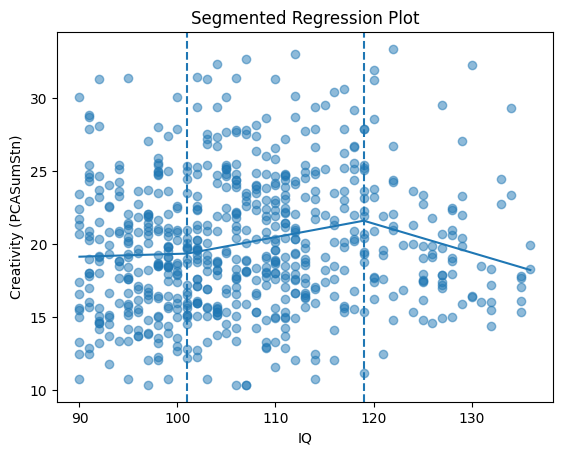

In [ ]:
import matplotlib.pyplot as plt

# Predictions
data_clean['pred'] = model_seg.predict(X_seg)

# Sort for smooth line
data_sorted = data_clean.sort_values('IQ')

# Plot
plt.figure()

plt.scatter(data_clean['IQ'], data_clean['PCASumStn'], alpha=0.5)
plt.plot(data_sorted['IQ'], data_sorted['pred'])

# Breakpoints
plt.axvline(x=101, linestyle='--')
plt.axvline(x=119, linestyle='--')

plt.xlabel('IQ')
plt.ylabel('Creativity (PCASumStn)')
plt.title('Segmented Regression Plot')

plt.show()

In [ ]:
model_seg.rsquared

np.float64(0.028248034152601464)

In [ ]:
import numpy as np
import statsmodels.api as sm

# Split data
male = data_clean[data_clean['Gender'] == 1].copy()
female = data_clean[data_clean['Gender'] == 2].copy()

def run_segmented(data):
    # Segments
    data['seg1'] = np.where(data['IQ'] >= 101, data['IQ'] - 101, 0)
    data['seg2'] = np.where(data['IQ'] >= 119, data['IQ'] - 119, 0)

    # Model
    X = sm.add_constant(data[['IQ', 'seg1', 'seg2']])
    y = data['PCASumStn']

    model = sm.OLS(y, X).fit()
    return model

# Run models
male_model = run_segmented(male)
female_model = run_segmented(female)

# Print summaries
print("=== Male ===")
print(male_model.summary())

print("\n=== Female ===")
print(female_model.summary())

=== Male ===
                            OLS Regression Results                            
Dep. Variable:              PCASumStn   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     6.819
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000181
Time:                        16:34:17   Log-Likelihood:                -978.30
No. Observations:                 325   AIC:                             1965.
Df Residuals:                     321   BIC:                             1980.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1393     10.707      1

In [ ]:
from scipy.stats import pearsonr

def corr_segments(data):
    def safe_corr(g):
        if len(g) > 2:
            return pearsonr(g['IQ'], g['PCASumStn'])
        else:
            return ("Not enough data", "NA")

    g1 = data[data['IQ'] < 101]
    g2 = data[(data['IQ'] >= 101) & (data['IQ'] < 119)]
    g3 = data[data['IQ'] >= 119]

    return (
        safe_corr(g1),
        safe_corr(g2),
        safe_corr(g3)
    )

male_corr = corr_segments(male)
female_corr = corr_segments(female)

print("Male:", male_corr)
print("Female:", female_corr)

Male: (PearsonRResult(statistic=np.float64(0.0054439346627881404), pvalue=np.float64(0.9586962310943244)), PearsonRResult(statistic=np.float64(0.1417008033625588), pvalue=np.float64(0.04933180978565173)), PearsonRResult(statistic=np.float64(0.11761810946452723), pvalue=np.float64(0.47577905719230384)))
Female: (PearsonRResult(statistic=np.float64(-0.08557523811754025), pvalue=np.float64(0.3653138250904915)), PearsonRResult(statistic=np.float64(0.042873165920383316), pvalue=np.float64(0.5999629760803817)), PearsonRResult(statistic=np.float64(-0.19384831868739902), pvalue=np.float64(0.11886028770267161)))


In [ ]:
# create squared term
data_clean['IQ2'] = data_clean['IQ']**2

X_quad = sm.add_constant(data_clean[['IQ', 'IQ2']])
y = data_clean['PCASumStn']

model_quad = sm.OLS(y, X_quad).fit()

model_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              PCASumStn   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     6.167
Date:                Wed, 17 Jun 2026   Prob (F-statistic):            0.00222
Time:                        16:34:17   Log-Likelihood:                -1923.7
No. Observations:                 657   AIC:                             3853.
Df Residuals:                     654   BIC:                             3867.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.8361     15.642     -1.460      0.145     -53.550       7.878
IQ             0.7468      0.286      2.610      0.009       0.185       1.309
IQ2           -0.0032      0.001     -2.471      0.014      -0.006      -0.001
==============================================================================
Omnibus:                       18.963   Durbin-Watson:                   1.269
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.179
Skew:                           0.425   Prob(JB):                     4.15e-05
Kurtosis:                       2.877   Cond. No.                     1.04e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.04e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model_seg.params

,0
const,17.382731
IQ,0.019361
seg1,0.105783
seg2,-0.323928


In [ ]:
data['IQ2'] = data['IQ']**2

In [ ]:
import statsmodels.api as sm

# Linear model (IQ → total creativity)
X_lin = sm.add_constant(data_clean[['IQ']])
y = data_clean['PCASumStn']

model_lin = sm.OLS(y, X_lin).fit()

model_lin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              PCASumStn   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.180
Date:                Wed, 17 Jun 2026   Prob (F-statistic):             0.0132
Time:                        16:34:17   Log-Likelihood:                -1926.8
No. Observations:                 657   AIC:                             3858.
Df Residuals:                     655   BIC:                             3867.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.5662      1.770      8.794      0.000      12.091      19.042
IQ             0.0409      0.016      2.486      0.013       0.009       0.073
==============================================================================
Omnibus:                       20.038   Durbin-Watson:                   1.243
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.269
Skew:                           0.431   Prob(JB):                     2.41e-05
Kurtosis:                       2.814   Cond. No.                     1.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
import statsmodels.api as sm

# Create squared term
data_clean['IQ2'] = data_clean['IQ'] ** 2

# Quadratic model
X_quad = sm.add_constant(data_clean[['IQ', 'IQ2']])
y = data_clean['PCASumStn']

model_quad = sm.OLS(y, X_quad).fit()

model_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              PCASumStn   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     6.167
Date:                Wed, 17 Jun 2026   Prob (F-statistic):            0.00222
Time:                        16:34:17   Log-Likelihood:                -1923.7
No. Observations:                 657   AIC:                             3853.
Df Residuals:                     654   BIC:                             3867.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.8361     15.642     -1.460      0.145     -53.550       7.878
IQ             0.7468      0.286      2.610      0.009       0.185       1.309
IQ2           -0.0032      0.001     -2.471      0.014      -0.006      -0.001
==============================================================================
Omnibus:                       18.963   Durbin-Watson:                   1.269
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               20.179
Skew:                           0.425   Prob(JB):                     4.15e-05
Kurtosis:                       2.877   Cond. No.                     1.04e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.04e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
print("Linear AIC:", model_lin.aic)
print("Quadratic AIC:", model_quad.aic)

print("Linear BIC:", model_lin.bic)
print("Quadratic BIC:", model_quad.bic)

Linear AIC: 3857.5316987657216
Quadratic AIC: 3853.426859946653
Linear BIC: 3866.5070668026906
Quadratic BIC: 3866.889912002107


Saved: all_figures/figure_2.png


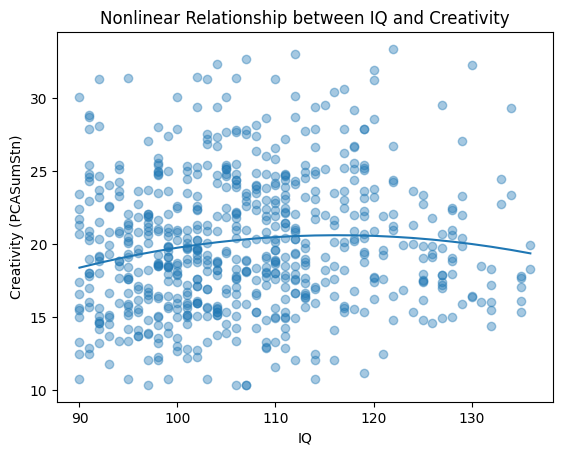

In [ ]:
import matplotlib.pyplot as plt

# Sort values
data_sorted = data_clean.sort_values('IQ').copy()

# Predictions
data_sorted['pred_quad'] = model_quad.predict(
    sm.add_constant(data_sorted[['IQ', 'IQ2']])
)

# Plot
plt.figure()

plt.scatter(data_clean['IQ'], data_clean['PCASumStn'], alpha=0.4)
plt.plot(data_sorted['IQ'], data_sorted['pred_quad'])

plt.xlabel('IQ')
plt.ylabel('Creativity (PCASumStn)')
plt.title('Nonlinear Relationship between IQ and Creativity')

plt.show()

In [ ]:
import statsmodels.api as sm

# Prepare data
data_clean['IQ2'] = data_clean['IQ']**2

# Interaction terms
data_clean['IQ_Gender'] = data_clean['IQ'] * data_clean['Gender']
data_clean['IQ_Grade'] = data_clean['IQ'] * data_clean['Grade']

# Predictors
X_int = sm.add_constant(data_clean[['IQ', 'IQ2', 'Gender', 'Grade', 'IQ_Gender', 'IQ_Grade']])

# --- Run for ALL creativity measures ---
targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

results = {}

for name, target in targets.items():
    y = data_clean[target]
    model = sm.OLS(y, X_int).fit()
    results[name] = model

# Print summaries
for name, model in results.items():
    print(f"\n===== {name} Creativity =====")
    print(model.summary())


===== Total Creativity =====
                            OLS Regression Results                            
Dep. Variable:              PCASumStn   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     11.97
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           9.00e-13
Time:                        16:34:18   Log-Likelihood:                -1895.4
No. Observations:                 657   AIC:                             3805.
Df Residuals:                     650   BIC:                             3836.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.9903 

In [ ]:
results = {
    "Linear R2": model_lin.rsquared,
    "Quadratic R2": model_quad.rsquared,
    "Interaction R2": results["Total"].rsquared,  # from interaction models

    "Linear AIC": model_lin.aic,
    "Quadratic AIC": model_quad.aic,
    "Interaction AIC": results["Total"].aic
}

results

{'Linear R2': np.float64(0.009347660124284007),
 'Quadratic R2': np.float64(0.01851015899581321),
 'Interaction R2': np.float64(0.09949491579603476),
 'Linear AIC': np.float64(3857.5316987657216),
 'Quadratic AIC': np.float64(3853.426859946653),
 'Interaction AIC': np.float64(3804.8487447856105)}

In [ ]:
import statsmodels.api as sm

# Data
data_full = df[['IQ', 'PCI', 'GCI',
                'PCAdrawstn', 'PCAcatestn', 'PCASumStn',
                'Gender', 'Grade']].dropna().copy()

# Nonlinear term
data_full['IQ2'] = data_full['IQ']**2

# Predictors
X_full = sm.add_constant(data_full[['IQ', 'IQ2', 'PCI', 'GCI', 'Gender', 'Grade']])

# Run for all creativity outcomes
targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

models_full = {}

for name, target in targets.items():
    y = data_full[target]
    model = sm.OLS(y, X_full).fit()
    models_full[name] = model

# Print results
for name, model in models_full.items():
    print(f"\n===== FULL MODEL: {name} =====")
    print(model.summary())


===== FULL MODEL: Total =====
                            OLS Regression Results                            
Dep. Variable:              PCASumStn   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     10.46
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           4.07e-11
Time:                        16:34:18   Log-Likelihood:                -2007.6
No. Observations:                 682   AIC:                             4029.
Df Residuals:                     675   BIC:                             4061.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.9933

In [ ]:
import statsmodels.api as sm

# Predictors (clean model)
X_clean = sm.add_constant(data_full[['IQ', 'IQ2', 'Gender', 'Grade']])

# Run for all creativity outcomes
targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

models_clean = {}

for name, target in targets.items():
    y = data_full[target]
    model = sm.OLS(y, X_clean).fit()
    models_clean[name] = model

# Print results
for name, model in models_clean.items():
    print(f"\n===== CLEAN MODEL: {name} =====")
    print(model.summary())


===== CLEAN MODEL: Total =====
                            OLS Regression Results                            
Dep. Variable:              PCASumStn   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     15.59
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           3.28e-12
Time:                        16:34:18   Log-Likelihood:                -2007.9
No. Observations:                 682   AIC:                             4026.
Df Residuals:                     677   BIC:                             4048.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.881

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X_ml = data_full[['IQ', 'PCI', 'GCI', 'Gender', 'Grade']]
y_ml = data_full['PCASumStn']

model_lasso = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5)
)

model_lasso.fit(X_ml, y_ml)

# get coefficients
coef = model_lasso.named_steps['lassocv'].coef_

list(zip(X_ml.columns, coef))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.249593436881696, tolerance: 1.1461601592124542
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 33.790765720905256, tolerance: 1.1461601592124542
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 56.651967626516125, tolerance: 1.1461601592124542
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergen

[('IQ', np.float64(0.0)),
 ('PCI', np.float64(0.0)),
 ('GCI', np.float64(0.0)),
 ('Gender', np.float64(-0.23033675550922203)),
 ('Grade', np.float64(1.0123158351817672))]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_rf = data_full[['IQ', 'PCI', 'GCI', 'Gender', 'Grade']]
y_rf = data_full['PCASumStn']

X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2_score(y_test, y_pred)

-0.05074122915671353

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Features
X_rf = data_full[['IQ', 'PCI', 'GCI', 'Gender', 'Grade']]

# Targets
targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

rf_results = {}

for name, target in targets.items():
    y_rf = data_full[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X_rf, y_rf, test_size=0.3, random_state=42
    )

    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    rf_results[name] = r2

print(rf_results)

{'Total': -0.05074122915671353, 'Drawing': -0.04178229533375877, 'Categorical': -0.04803155118316238}


Saved: all_figures/figure_3.png


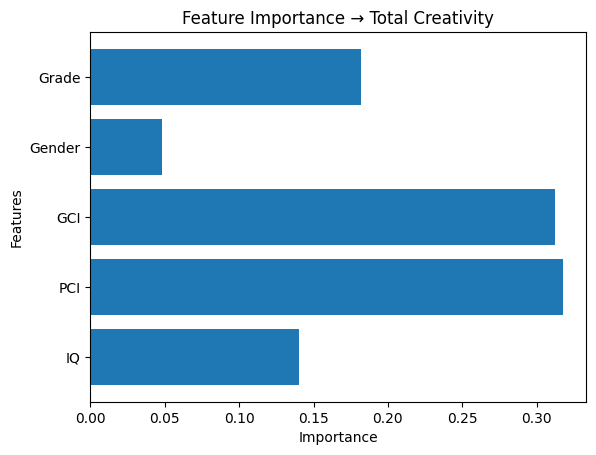

Saved: all_figures/figure_4.png


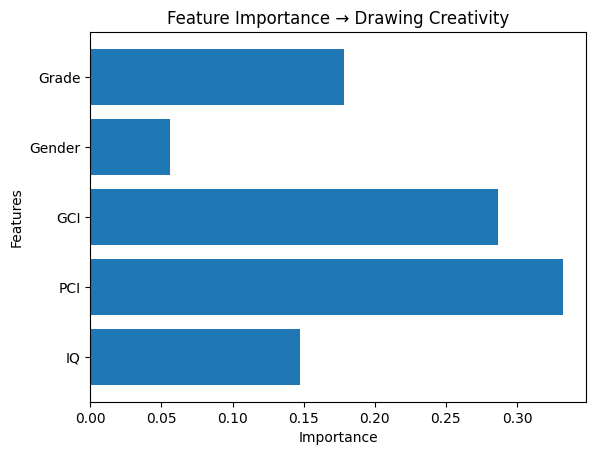

Saved: all_figures/figure_5.png


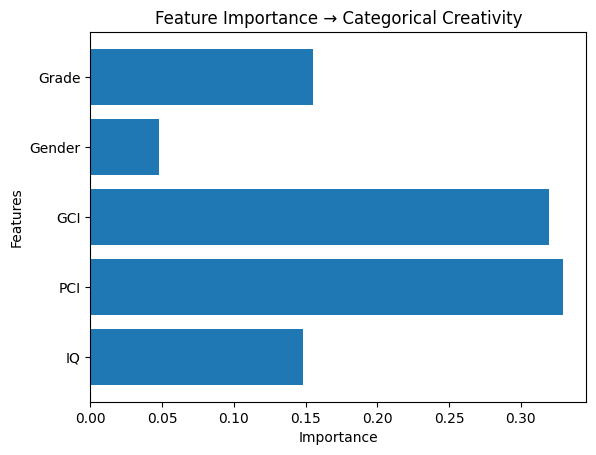

In [ ]:
import matplotlib.pyplot as plt

# Features
X_rf = data_full[['IQ', 'PCI', 'GCI', 'Gender', 'Grade']]
features = X_rf.columns

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    y_rf = data_full[target]

    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_rf, y_rf)

    importance = rf.feature_importances_

    plt.figure()
    plt.barh(features, importance)
    plt.title(f"Feature Importance → {name} Creativity")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()

In [ ]:
import statsmodels.api as sm

# Drawing creativity model
y_draw = data_full['PCAdrawstn']
model_draw = sm.OLS(y_draw, X_clean).fit()

print("===== Drawing Creativity =====")
print(model_draw.summary())

# Categorical creativity model
y_cat = data_full['PCAcatestn']
model_cat = sm.OLS(y_cat, X_clean).fit()

print("\n===== Categorical Creativity =====")
print(model_cat.summary())

===== Drawing Creativity =====
                            OLS Regression Results                            
Dep. Variable:             PCAdrawstn   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     21.13
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.97e-16
Time:                        16:34:44   Log-Likelihood:                -1676.2
No. Observations:                 682   AIC:                             3362.
Df Residuals:                     677   BIC:                             3385.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.8898

Saved: all_figures/figure_6.png


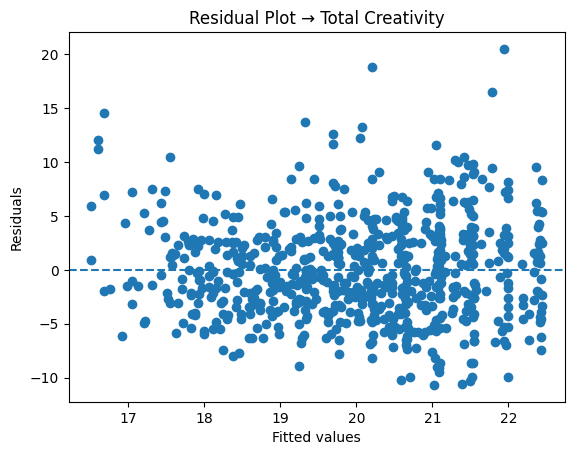

Saved: all_figures/figure_7.png


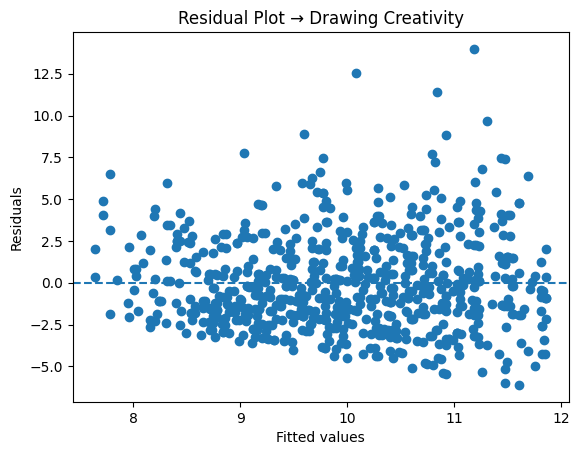

Saved: all_figures/figure_8.png


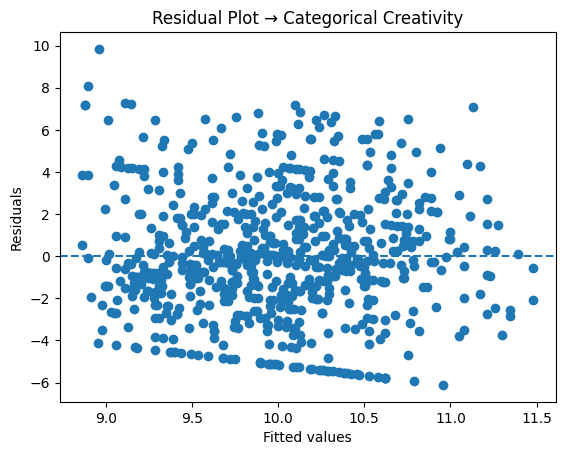

In [ ]:
import matplotlib.pyplot as plt

models = {
    "Total": models_clean["Total"],
    "Drawing": models_clean["Drawing"],
    "Categorical": models_clean["Categorical"]
}

for name, model in models.items():
    residuals = model.resid
    fitted = model.fittedvalues

    plt.figure()
    plt.scatter(fitted, residuals)
    plt.axhline(y=0, linestyle='--')
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot → {name} Creativity")
    plt.show()

Saved: all_figures/figure_9.png


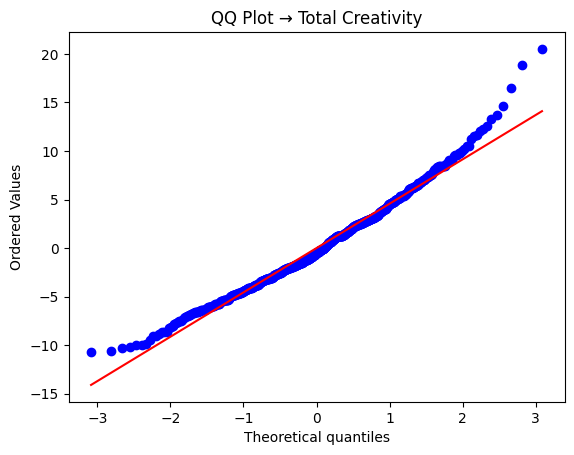

Saved: all_figures/figure_10.png


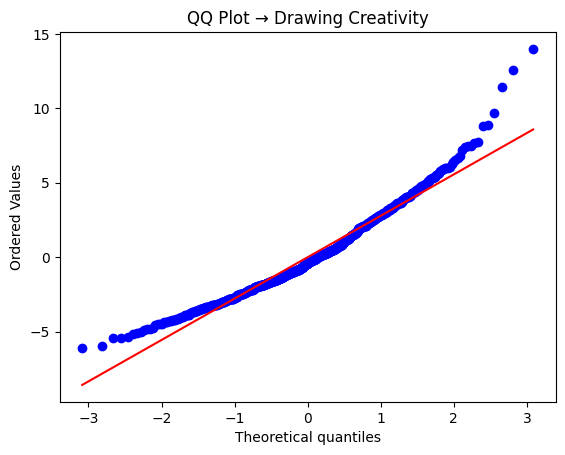

Saved: all_figures/figure_11.png


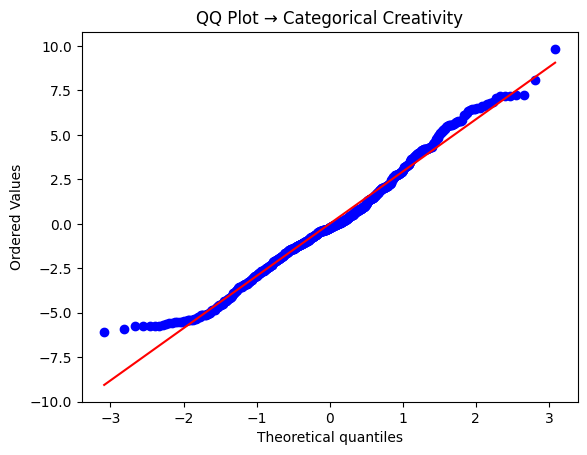

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

models = {
    "Total": models_clean["Total"],
    "Drawing": models_clean["Drawing"],
    "Categorical": models_clean["Categorical"]
}

for name, model in models.items():
    residuals = model.resid

    plt.figure()
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot → {name} Creativity")
    plt.show()

Saved: all_figures/figure_12.png


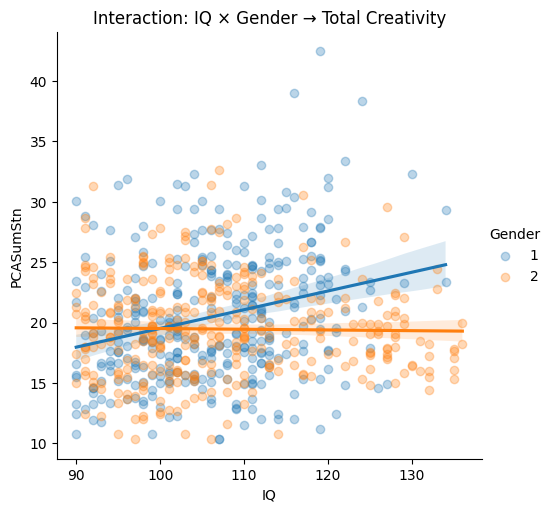

Saved: all_figures/figure_13.png


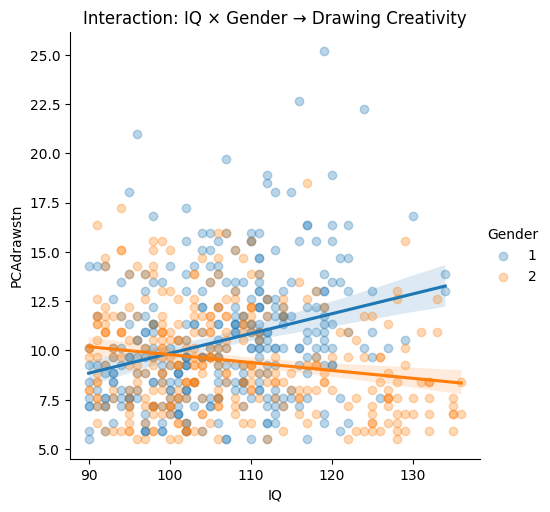

Saved: all_figures/figure_14.png


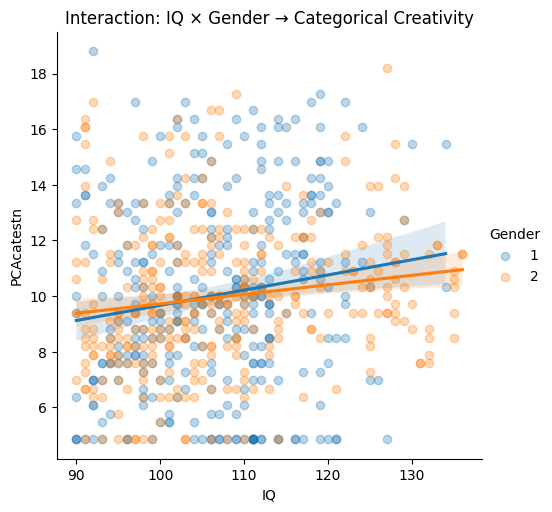

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    sns.lmplot(
        x='IQ',
        y=target,
        hue='Gender',
        data=data_full,
        scatter_kws={'alpha': 0.3}
    )

    plt.title(f"Interaction: IQ × Gender → {name} Creativity")
    plt.show()

Saved: all_figures/figure_15.png


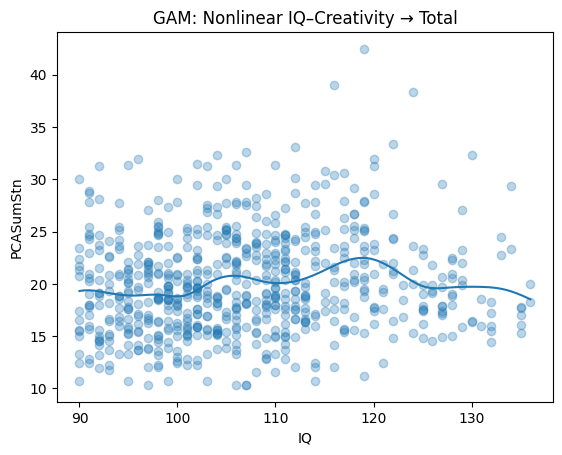

Saved: all_figures/figure_16.png


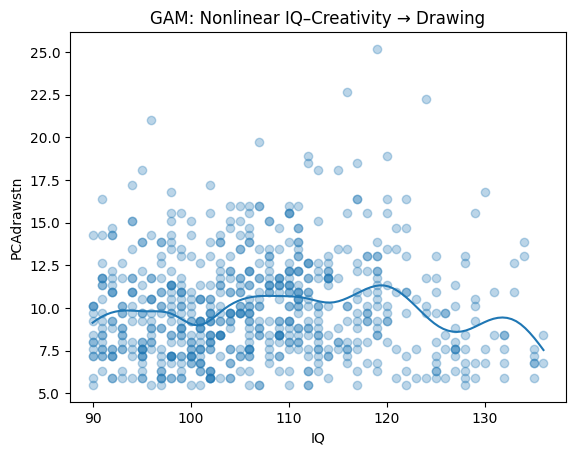

Saved: all_figures/figure_17.png


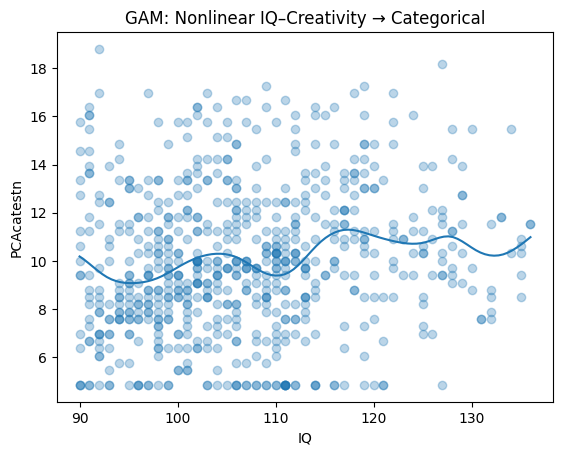

In [ ]:
from pygam import LinearGAM, s
import numpy as np
import matplotlib.pyplot as plt

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    X = data_full[['IQ']].values
    y = data_full[target].values

    gam = LinearGAM(s(0)).fit(X, y)

    XX = np.linspace(X.min(), X.max(), 100)

    plt.figure()
    plt.plot(XX, gam.predict(XX))
    plt.scatter(X, y, alpha=0.3)
    plt.title(f"GAM: Nonlinear IQ–Creativity → {name}")
    plt.xlabel("IQ")
    plt.ylabel(target)
    plt.show()

In [ ]:
import statsmodels.formula.api as smf

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

models_q = {}

for name, target in targets.items():
    formula = f"{target} ~ IQ + Grade + Gender"
    model_q = smf.quantreg(formula, data_full).fit(q=0.5)
    models_q[name] = model_q

for name, model in models_q.items():
    print(f"\n===== Quantile Regression (Median) → {name} =====")
    print(model.summary())


===== Quantile Regression (Median) → Total =====
                         QuantReg Regression Results                          
Dep. Variable:              PCASumStn   Pseudo R-squared:              0.03929
Model:                       QuantReg   Bandwidth:                       2.495
Method:                 Least Squares   Sparsity:                        11.95
Date:                Wed, 17 Jun 2026   No. Observations:                  682
Time:                        16:35:12   Df Residuals:                      678
                                        Df Model:                            3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.7095      2.380      7.861      0.000      14.036      23.383
IQ            -0.0165      0.023     -0.721      0.471      -0.061       0.028
Grade          0.5305      0.093      5.715      0.000       0.348       0.713
Ge

In [ ]:
import os

# Create folder safely (no error if exists)
os.makedirs("figures", exist_ok=True)

print("Folder 'figures' is ready 👍")

Folder 'figures' is ready 👍


In [ ]:
import pwlf
import numpy as np
import statsmodels.api as sm

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

pwlf_models = {}

for name, target in targets.items():
    # Prepare data
    x = data_clean['IQ'].values
    y = data_clean[target].values

    # Fit piecewise model (1 breakpoint)
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    bp = breaks[1]

    print(f"\n===== {name} =====")
    print("Estimated breakpoints:", breaks)
    print("Main breakpoint:", bp)

    # Build segmented variable
    data_pwlf = data_clean.copy()
    data_pwlf['seg1'] = np.where(data_pwlf['IQ'] >= bp, data_pwlf['IQ'] - bp, 0)

    # Regression
    X_pwlf = sm.add_constant(data_pwlf[['IQ', 'seg1']])
    y_pwlf = data_pwlf[target]

    model = sm.OLS(y_pwlf, X_pwlf).fit()
    pwlf_models[name] = model

    print(model.summary())


===== Total =====
Estimated breakpoints: [ 90.        119.0000003 136.       ]
Main breakpoint: 119.00000029972003
                            OLS Regression Results                            
Dep. Variable:              PCASumStn   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     8.837
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000163
Time:                        16:35:13   Log-Likelihood:                -1921.1
No. Observations:                 657   AIC:                             3848.
Df Residuals:                     654   BIC:                             3862.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

In [ ]:
import numpy as np
import statsmodels.api as sm
import pwlf

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    print(f"\n===== Model Comparison → {name} =====")

    # Data
    x = data_clean['IQ'].values
    y = data_clean[target].values

    # --- Linear ---
    X_lin = sm.add_constant(data_clean[['IQ']])
    model_lin = sm.OLS(data_clean[target], X_lin).fit()

    # --- Quadratic ---
    data_clean['IQ2'] = data_clean['IQ']**2
    X_quad = sm.add_constant(data_clean[['IQ', 'IQ2']])
    model_quad = sm.OLS(data_clean[target], X_quad).fit()

    # --- PWLF ---
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    y_hat_pwlf = my_pwlf.predict(x)

    rss_pwlf = np.sum((y - y_hat_pwlf)**2)

    n = len(y)
    k = 3  # intercept + slopes
    aic_pwlf = n * np.log(rss_pwlf/n) + 2*k

    # --- Print ---
    print("Linear AIC:", model_lin.aic)
    print("Quadratic AIC:", model_quad.aic)
    print("Segmented (pwlf) AIC:", aic_pwlf)


===== Model Comparison → Total =====
Linear AIC: 3857.5316987657216
Quadratic AIC: 3853.426859946653
Segmented (pwlf) AIC: 1983.6975381588102

===== Model Comparison → Drawing =====
Linear AIC: 3221.9758171273206
Quadratic AIC: 3206.7898886109656
Segmented (pwlf) AIC: 1336.094968474071

===== Model Comparison → Categorical =====
Linear AIC: 3291.5268868050443
Quadratic AIC: 3293.513888711529
Segmented (pwlf) AIC: 1426.2055204015942


Saved: all_figures/figure_18.png


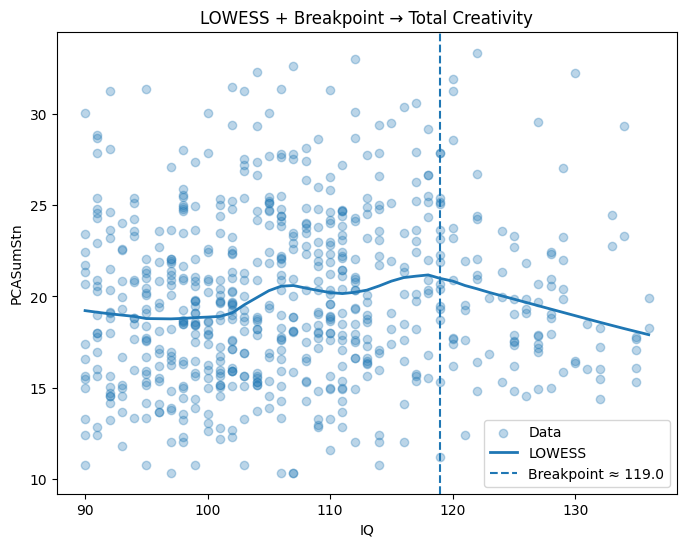

Saved: all_figures/figure_19.png


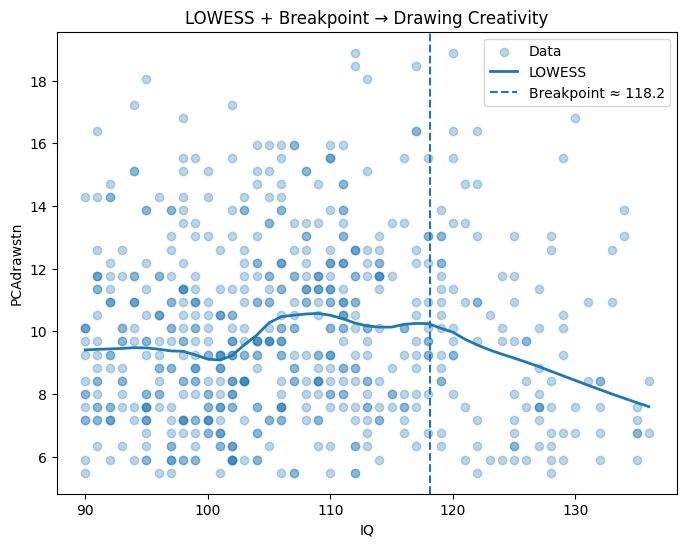

Saved: all_figures/figure_20.png


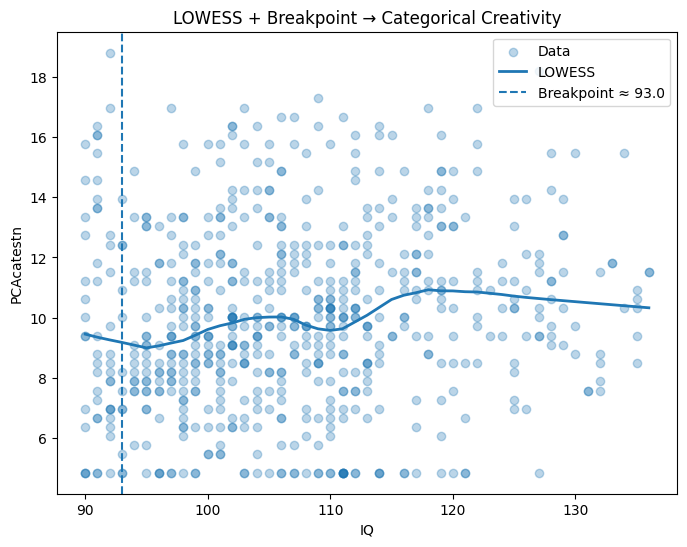

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pwlf
import numpy as np

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    x = data_clean['IQ'].values
    y = data_clean[target].values

    # LOWESS
    lowess = sm.nonparametric.lowess(y, x, frac=0.3)

    # PWLF breakpoint
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)
    bp = breaks[1]

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(x, y, alpha=0.3, label="Data")
    plt.plot(lowess[:,0], lowess[:,1], linewidth=2, label="LOWESS")
    plt.axvline(bp, linestyle='--', label=f'Breakpoint ≈ {bp:.1f}')

    plt.xlabel("IQ")
    plt.ylabel(target)
    plt.title(f"LOWESS + Breakpoint → {name} Creativity")
    plt.legend()
    plt.show()

In [ ]:
import numpy as np
import statsmodels.api as sm

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    data_exp = data_clean.copy()

    # Fixed breakpoints (literature-based)
    data_exp['seg1'] = np.where(data_exp['IQ'] >= 101, data_exp['IQ'] - 101, 0)
    data_exp['seg2'] = np.where(data_exp['IQ'] >= 119, data_exp['IQ'] - 119, 0)

    X_exp = sm.add_constant(data_exp[['IQ', 'seg1', 'seg2']])
    y_exp = data_exp[target]

    model_exp = sm.OLS(y_exp, X_exp).fit()

    print(f"\n--- Exploratory Segmented Model → {name} ---")
    print(model_exp.summary())


--- Exploratory Segmented Model → Total ---
                            OLS Regression Results                            
Dep. Variable:              PCASumStn   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     6.327
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000312
Time:                        16:35:24   Log-Likelihood:                -1920.4
No. Observations:                 657   AIC:                             3849.
Df Residuals:                     653   BIC:                             3867.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  


===== MAIN SEGMENTED → Total =====
Estimated breakpoint: 119.00
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     8.837
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000163
Time:                        16:35:25   Log-Likelihood:                -1921.1
No. Observations:                 657   AIC:                             3848.
Df Residuals:                     654   BIC:                             3862.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

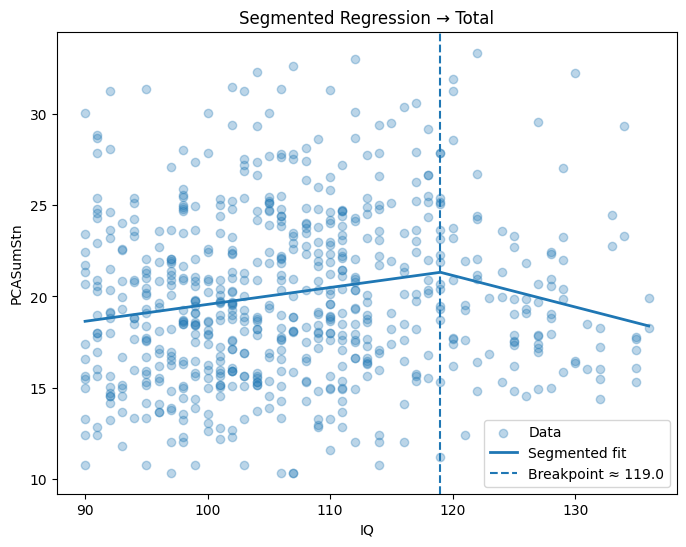


===== MAIN SEGMENTED → Drawing =====
Estimated breakpoint: 117.85
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     11.92
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           8.20e-06
Time:                        16:35:31   Log-Likelihood:                -1597.3
No. Observations:                 657   AIC:                             3201.
Df Residuals:                     654   BIC:                             3214.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

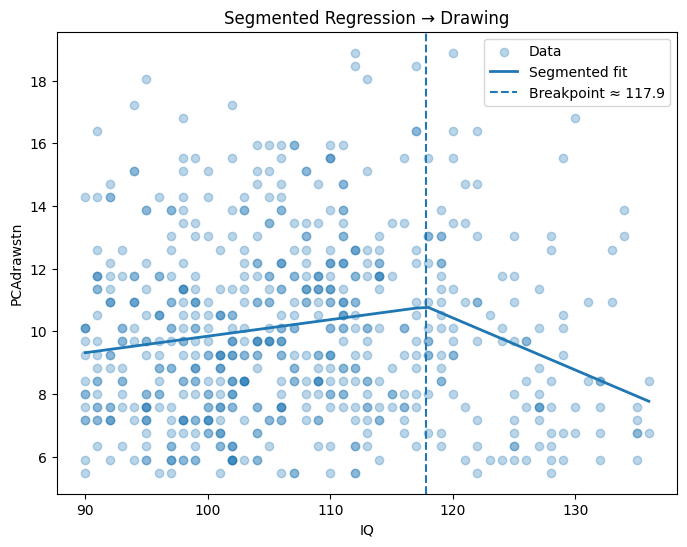


===== MAIN SEGMENTED → Categorical =====
Estimated breakpoint: 93.00
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     7.479
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000614
Time:                        16:35:35   Log-Likelihood:                -1642.3
No. Observations:                 657   AIC:                             3291.
Df Residuals:                     654   BIC:                             3304.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

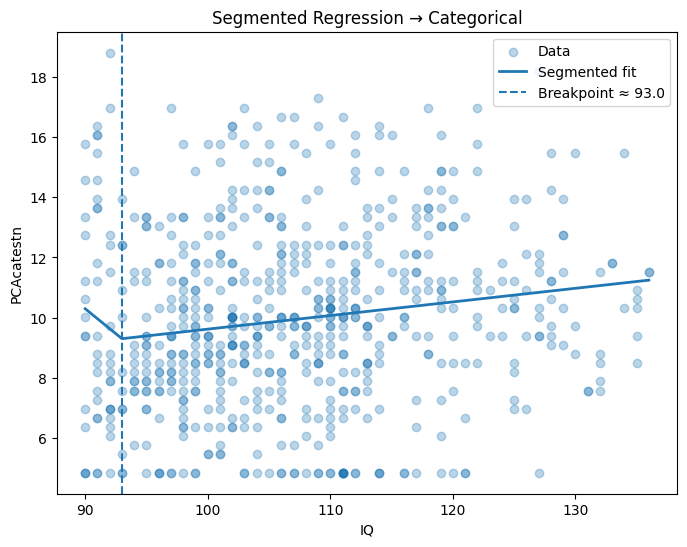

In [ ]:
import numpy as np
import statsmodels.api as sm
import pwlf
import matplotlib.pyplot as plt

targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

for name, target in targets.items():
    print(f"\n===== MAIN SEGMENTED → {name} =====")

    # Prepare data
    data_main = data_clean.copy()
    x = data_main['IQ'].values
    y = data_main[target].values

    # 1. Estimate breakpoint
    pwlf_model = pwlf.PiecewiseLinFit(x, y)
    breaks = pwlf_model.fit(2)
    bp = breaks[1]

    print(f"Estimated breakpoint: {bp:.2f}")

    # 2. Create segment
    data_main['seg'] = np.where(data_main['IQ'] >= bp, data_main['IQ'] - bp, 0)

    # 3. Fit model
    X_main = sm.add_constant(data_main[['IQ', 'seg']])
    model_main = sm.OLS(y, X_main).fit()

    print(model_main.summary())

    # 4. Plot
    data_sorted = data_main.sort_values('IQ')
    X_sorted = sm.add_constant(data_sorted[['IQ', 'seg']])
    pred = model_main.predict(X_sorted)

    plt.figure(figsize=(8,6))
    plt.scatter(x, y, alpha=0.3, label='Data')
    plt.plot(data_sorted['IQ'], pred, linewidth=2, label='Segmented fit')
    plt.axvline(bp, linestyle='--', label=f'Breakpoint ≈ {bp:.1f}')

    plt.xlabel('IQ')
    plt.ylabel(target)
    plt.title(f'Segmented Regression → {name}')
    plt.legend()
    plt.show()

Saved: all_figures/figure_24.png


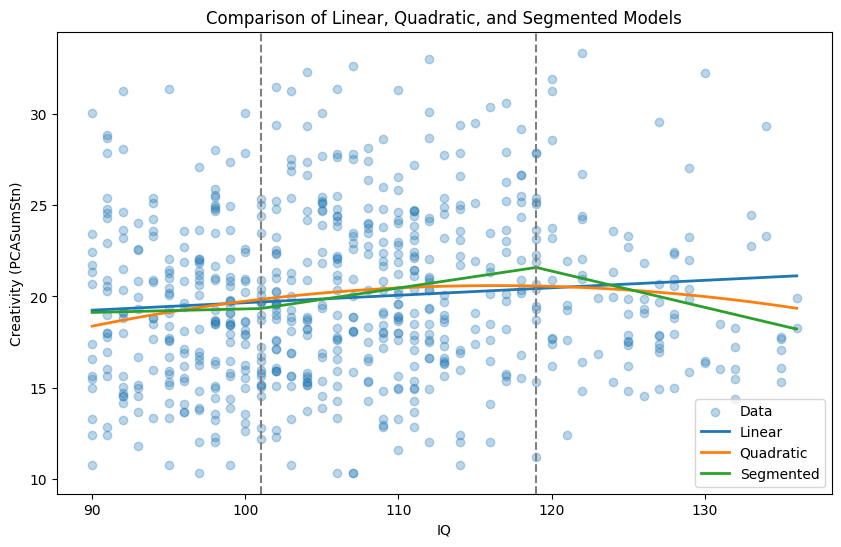

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Prepare data
df = data_clean.copy()
df = df.sort_values('IQ')

# Linear model
X_lin = sm.add_constant(df[['IQ']])
model_lin = sm.OLS(df['PCASumStn'], X_lin).fit()
df['pred_lin'] = model_lin.predict(X_lin)

# Quadratic model
df['IQ2'] = df['IQ']**2
X_quad = sm.add_constant(df[['IQ', 'IQ2']])
model_quad = sm.OLS(df['PCASumStn'], X_quad).fit()
df['pred_quad'] = model_quad.predict(X_quad)

# Segmented model
df['seg1'] = np.where(df['IQ'] >= 101, df['IQ'] - 101, 0)
df['seg2'] = np.where(df['IQ'] >= 119, df['IQ'] - 119, 0)

X_seg = sm.add_constant(df[['IQ', 'seg1', 'seg2']])
model_seg = sm.OLS(df['PCASumStn'], X_seg).fit()
df['pred_seg'] = model_seg.predict(X_seg)

# Plot
plt.figure(figsize=(10,6))

# Scatter
plt.scatter(df['IQ'], df['PCASumStn'], alpha=0.3, label='Data')

# Lines
plt.plot(df['IQ'], df['pred_lin'], label='Linear', linewidth=2)
plt.plot(df['IQ'], df['pred_quad'], label='Quadratic', linewidth=2)
plt.plot(df['IQ'], df['pred_seg'], label='Segmented', linewidth=2)

# Breakpoints
plt.axvline(101, linestyle='--', color='gray')
plt.axvline(119, linestyle='--', color='gray')

# Labels
plt.xlabel('IQ')
plt.ylabel('Creativity (PCASumStn)')
plt.title('Comparison of Linear, Quadratic, and Segmented Models')
plt.legend()

plt.show()

Saved: all_figures/figure_25.png


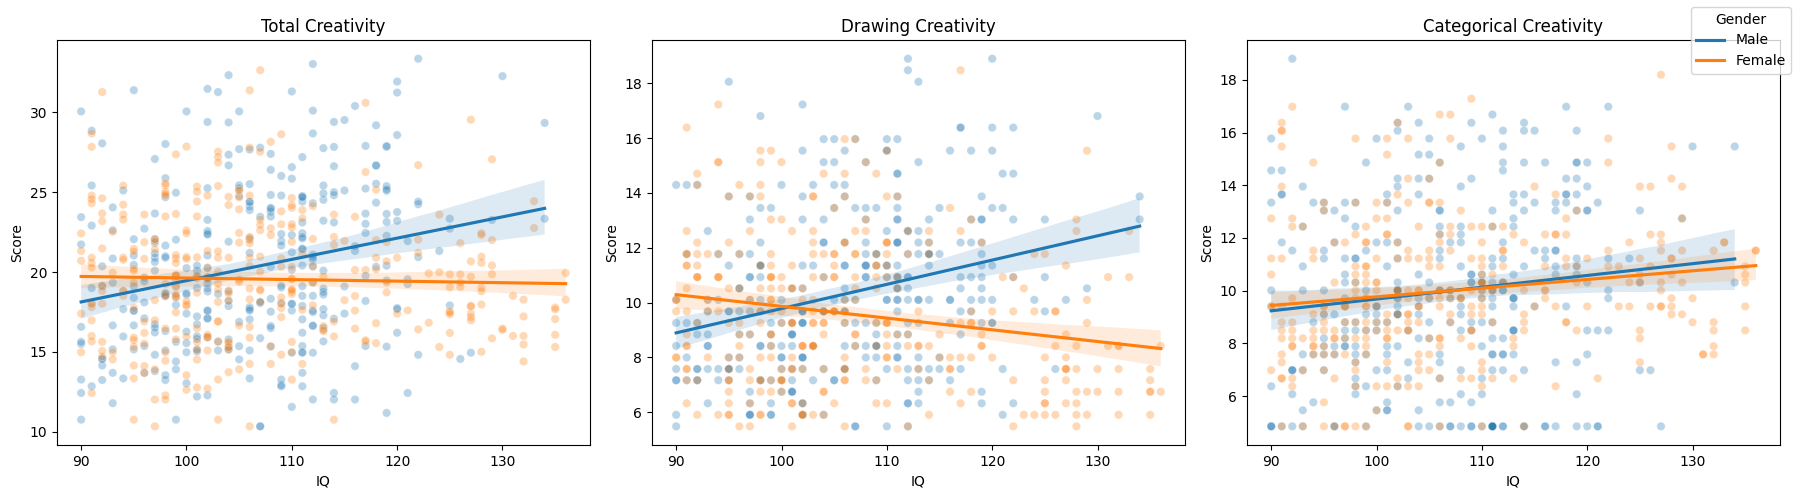

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Copy data ---
df_plot = data_clean.copy()

# --- Map gender ---
df_plot['Gender'] = df_plot['Gender'].map({1: 'Male', 2: 'Female'})

# --- Targets ---
targets = {
    "Total": 'PCASumStn',
    "Drawing": 'PCAdrawstn',
    "Categorical": 'PCAcatestn'
}

# --- Colors ---
palette = {'Male': '#1f77b4', 'Female': '#ff7f0e'}

# --- Create subplots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# --- Loop ---
for ax, (name, target) in zip(axes, targets.items()):

    # Scatter
    sns.scatterplot(
        x='IQ',
        y=target,
        hue='Gender',
        data=df_plot,
        palette=palette,
        alpha=0.3,
        ax=ax,
        legend=False  # avoid duplicate legends
    )

    # Regression line for each gender
    for gender, color in palette.items():
        subset = df_plot[df_plot['Gender'] == gender]
        sns.regplot(
            x='IQ',
            y=target,
            data=subset,
            scatter=False,
            ax=ax,
            color=color,
            label=gender
        )

    ax.set_title(name + " Creativity")
    ax.set_xlabel("IQ")
    ax.set_ylabel("Score")

# --- One legend for entire figure ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Gender", loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
print(data_clean.shape)
print(data_clean.isnull().sum())

(657, 18)
Grade          0
Age            0
Gender         0
PCI            0
GCI            0
IQ             0
PCAdrawstn     0
PCAcatestn     0
PCASumStn      0
CIndex         0
Parerating     0
Teachrating    0
seg1           0
seg2           0
pred           0
IQ2            0
IQ_Gender      0
IQ_Grade       0
dtype: int64


In [ ]:
extension_data = data_clean[['Grade','Age','Gender',
                             'PCI','GCI','IQ',
                             'PCAdrawstn','PCAcatestn',
                             'PCASumStn','CIndex',
                             'Parerating','Teachrating']].copy()

print(extension_data.shape)

(657, 12)


In [ ]:
outcomes = {
    "Drawing": "PCAdrawstn",
    "Category": "PCAcatestn",
    "Total": "PCASumStn"
}

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

results_table = []

for name, target in outcomes.items():

    df = extension_data.copy()

    # ------------------
    # Linear Model
    # ------------------
    X_lin = sm.add_constant(df[['IQ']])
    y = df[target]

    model_lin = sm.OLS(y, X_lin).fit()

    # ------------------
    # Quadratic Model
    # ------------------
    df['IQ2'] = df['IQ']**2

    X_quad = sm.add_constant(df[['IQ', 'IQ2']])

    model_quad = sm.OLS(y, X_quad).fit()

    # ------------------
    # Segmented Model
    # ------------------
    df['seg1'] = np.where(df['IQ'] >= 101,
                          df['IQ'] - 101, 0)

    df['seg2'] = np.where(df['IQ'] >= 119,
                          df['IQ'] - 119, 0)

    X_seg = sm.add_constant(df[['IQ', 'seg1', 'seg2']])

    model_seg = sm.OLS(y, X_seg).fit()

    results_table.append({
        'Outcome': name,

        'Linear_R2': round(model_lin.rsquared, 3),
        'Quadratic_R2': round(model_quad.rsquared, 3),
        'Segmented_R2': round(model_seg.rsquared, 3),

        'Linear_AIC': round(model_lin.aic, 2),
        'Quadratic_AIC': round(model_quad.aic, 2),
        'Segmented_AIC': round(model_seg.aic, 2)
    })

results_df = pd.DataFrame(results_table)

results_df

,Outcome,Linear_R2,Quadratic_R2,Segmented_R2,Linear_AIC,Quadratic_AIC,Segmented_AIC
0,Drawing,0.000,0.026,0.037,3221.98,3206.79,3201.53
1,Category,0.018,0.018,0.020,3291.53,3293.51,3294.60
2,Total,0.009,0.019,0.028,3857.53,3853.43,3848.88


In [ ]:
import pandas as pd
import statsmodels.api as sm

predictors = ['IQ', 'PCI', 'GCI']

results = []

for outcome_name, outcome in outcomes.items():

    for predictor in predictors:

        X = sm.add_constant(extension_data[[predictor]])
        y = extension_data[outcome]

        model = sm.OLS(y, X).fit()

        results.append({
            'Outcome': outcome_name,
            'Predictor': predictor,
            'Beta': round(model.params[predictor], 3),
            'p_value': round(model.pvalues[predictor], 4),
            'R2': round(model.rsquared, 3)
        })

predictor_results = pd.DataFrame(results)

predictor_results

,Outcome,Predictor,Beta,p_value,R2
0,Drawing,IQ,0.004,0.7148,0.000
1,Drawing,PCI,-0.002,0.7989,0.000
2,Drawing,GCI,0.009,0.3472,0.001
3,Category,IQ,0.037,0.0005,0.018
4,Category,PCI,0.039,0.0001,0.022
5,Category,GCI,0.027,0.0105,0.010
6,Total,IQ,0.041,0.0132,0.009
7,Total,PCI,0.037,0.0189,0.008
8,Total,GCI,0.037,0.0246,0.008


RQ2

Do pictorial intelligence, geometric intelligence, and full-scale IQ contribute differently to creativity outcomes?

In [ ]:
import statsmodels.api as sm
import pandas as pd

results = []

for outcome_name, outcome in outcomes.items():

    # Model 1
    X1 = sm.add_constant(
        extension_data[['IQ','Grade','Gender']]
    )

    model1 = sm.OLS(
        extension_data[outcome],
        X1
    ).fit()

    # Model 2
    X2 = sm.add_constant(
        extension_data[['IQ',
                        'Grade',
                        'Gender',
                        'Parerating',
                        'Teachrating']]
    )

    model2 = sm.OLS(
        extension_data[outcome],
        X2
    ).fit()

    results.append({
        'Outcome': outcome_name,
        'Model1_R2': round(model1.rsquared,3),
        'Model2_R2': round(model2.rsquared,3),
        'Delta_R2': round(
            model2.rsquared-model1.rsquared,
            3
        )
    })

pd.DataFrame(results)

,Outcome,Model1_R2,Model2_R2,Delta_R2
0,Drawing,0.095,0.107,0.012
1,Category,0.028,0.036,0.008
2,Total,0.071,0.082,0.012


In [ ]:
# =====================================================
# Center IQ before creating quadratic term
# =====================================================

extension_data = extension_data.copy()

# Center IQ around its mean
extension_data['IQ_c'] = (
    extension_data['IQ']
    - extension_data['IQ'].mean()
)

# Quadratic term from centered IQ
extension_data['IQ_c2'] = (
    extension_data['IQ_c'] ** 2
)

# Check
print("Mean IQ:", extension_data['IQ'].mean())
print("Mean IQ_c:", extension_data['IQ_c'].mean())

extension_data[['IQ', 'IQ_c', 'IQ_c2']].head()

Mean IQ: 107.00304414003044
Mean IQ_c: 1.7303932682133337e-15


,IQ,IQ_c,IQ_c2
0,98.0,-9.003044,81.054804
2,93.0,-14.003044,196.085245
3,102.0,-5.003044,25.030451
4,94.0,-13.003044,169.079157
5,97.0,-10.003044,100.060892


In [ ]:
import pandas as pd
import statsmodels.api as sm

quad_results = []

for name, target in outcomes.items():

    X_quad = sm.add_constant(
        extension_data[['IQ_c', 'IQ_c2']]
    )

    y = extension_data[target]

    model = sm.OLS(y, X_quad).fit()

    quad_results.append({
        'Outcome': name,
        'R2': round(model.rsquared, 3),
        'AIC': round(model.aic, 2),
        'IQ_c_p': round(model.pvalues['IQ_c'], 4),
        'IQ_c2_p': round(model.pvalues['IQ_c2'], 4),
        'Condition_Number': round(model.condition_number, 2)
    })

    print(f"\n===== {name} =====")
    print(model.summary())

quad_results_df = pd.DataFrame(quad_results)

print("\n\nSUMMARY TABLE")
display(quad_results_df)


===== Drawing =====
                            OLS Regression Results                            
Dep. Variable:             PCAdrawstn   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     8.735
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000180
Time:                        16:35:58   Log-Likelihood:                -1600.4
No. Observations:                 657   AIC:                             3207.
Df Residuals:                     654   BIC:                             3220.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3364      0.14

,Outcome,R2,AIC,IQ_c_p,IQ_c2_p,Condition_Number
0,Drawing,0.026,3206.79,0.0365,0.0000,250.06
1,Category,0.018,3293.51,0.0020,0.9095,250.06
2,Total,0.019,3853.43,0.0010,0.0137,250.06


In [ ]:
import pwlf
import numpy as np
import pandas as pd

bp_results = []

for name, target in outcomes.items():

    x = extension_data['IQ'].values
    y = extension_data[target].values

    my_pwlf = pwlf.PiecewiseLinFit(x, y)

    breaks = my_pwlf.fit(2)

    bp_results.append({
        'Outcome': name,
        'Breakpoint': round(breaks[1],2)
    })

bp_df = pd.DataFrame(bp_results)

bp_df

,Outcome,Breakpoint
0,Drawing,118.16
1,Category,93.00
2,Total,119.00


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

seg_results = []

for name, target in outcomes.items():

    x = extension_data['IQ'].values
    y = extension_data[target].values

    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    breaks = my_pwlf.fit(2)

    bp = breaks[1]

    temp = extension_data.copy()

    temp['seg1'] = np.where(
        temp['IQ'] >= bp,
        temp['IQ'] - bp,
        0
    )

    X = sm.add_constant(
        temp[['IQ','seg1']]
    )

    model = sm.OLS(
        temp[target],
        X
    ).fit()

    seg_results.append({
        'Outcome': name,
        'Breakpoint': round(bp,2),
        'R2': round(model.rsquared,3),
        'seg1_p': round(model.pvalues['seg1'],4)
    })

seg_df = pd.DataFrame(seg_results)

seg_df

,Outcome,Breakpoint,R2,seg1_p
0,Drawing,118.16,0.035,0.0000
1,Category,93.00,0.022,0.0930
2,Total,119.00,0.026,0.0008


In [ ]:
import pandas as pd
from scipy.stats import pearsonr

threshold_results = []

for name, target in outcomes.items():

    bp = float(
        bp_df.loc[
            bp_df['Outcome']==name,
            'Breakpoint'
        ]
    )

    low = extension_data[
        extension_data['IQ'] < bp
    ]

    high = extension_data[
        extension_data['IQ'] >= bp
    ]

    r_low, p_low = pearsonr(
        low['IQ'],
        low[target]
    )

    r_high, p_high = pearsonr(
        high['IQ'],
        high[target]
    )

    threshold_results.append({
        'Outcome': name,
        'Breakpoint': round(bp,2),
        'Low_r': round(r_low,3),
        'Low_p': round(p_low,4),
        'High_r': round(r_high,3),
        'High_p': round(p_high,4)
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

/tmp/ipykernel_2197/68748253.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bp = float(


,Outcome,Breakpoint,Low_r,Low_p,High_r,High_p
0,Drawing,118.16,0.142,0.0008,-0.286,0.0031
1,Category,93.00,-0.043,0.7637,0.160,0.0001
2,Total,119.00,0.148,0.0005,-0.214,0.0283


In [ ]:
final_models = pd.DataFrame({
    'Outcome':['Drawing','Category','Total'],
    'Linear_R2':[0.000,0.018,0.009],
    'Quadratic_R2':[0.026,0.018,0.019],
    'Segmented_R2':[0.035,0.022,0.026]
})

final_models

,Outcome,Linear_R2,Quadratic_R2,Segmented_R2
0,Drawing,0.000,0.026,0.035
1,Category,0.018,0.018,0.022
2,Total,0.009,0.019,0.026


In [ ]:
!pip install nca

ERROR: Could not find a version that satisfies the requirement nca (from versions: none)
ERROR: No matching distribution found for nca


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

In [ ]:
features = [
    'IQ',
    'PCI',
    'GCI',
    'Age',
    'Grade',
    'Gender',
    'Parerating',
    'Teachrating'
]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

targets = {
    "Drawing": "PCAdrawstn",
    "Category": "PCAcatestn",
    "Total": "PCASumStn"
}

rf_results = []

for name, target in targets.items():

    X = extension_data[features]
    y = extension_data[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42
    )

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)

    rf_results.append({
        "Outcome": name,
        "R2": round(r2_score(y_test, pred),3),
        "MAE": round(mean_absolute_error(y_test,pred),3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test,pred)),3)
    })

rf_results_df = pd.DataFrame(rf_results)

rf_results_df

,Outcome,R2,MAE,RMSE
0,Drawing,0.141,2.108,2.627
1,Category,-0.102,2.320,3.025
2,Total,-0.010,3.745,4.563


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

for name, target in targets.items():

    X = extension_data[features]
    y = extension_data[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    rf.fit(X,y)

    importance = pd.DataFrame({
        'Feature': features,
        'Importance': rf.feature_importances_
    }).sort_values(
        'Importance',
        ascending=False
    )

    print("\n")
    print("="*50)
    print(name)
    print("="*50)
    print(importance)



Drawing
       Feature  Importance
1          PCI    0.191691
6   Parerating    0.170632
2          GCI    0.163331
7  Teachrating    0.158484
4        Grade    0.114313
0           IQ    0.108778
3          Age    0.054761
5       Gender    0.038008


Category
       Feature  Importance
1          PCI    0.198598
2          GCI    0.184348
7  Teachrating    0.179213
6   Parerating    0.164536
0           IQ    0.099480
4        Grade    0.083482
3          Age    0.061433
5       Gender    0.028910


Total
       Feature  Importance
7  Teachrating    0.177187
6   Parerating    0.174159
2          GCI    0.174027
1          PCI    0.172479
4        Grade    0.101803
0           IQ    0.097229
3          Age    0.070673
5       Gender    0.032441


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

X = extension_data[features]
y = extension_data['PCAdrawstn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("R² =", r2_score(y_test,pred))
print("MAE =", mean_absolute_error(y_test,pred))
print("RMSE =", np.sqrt(((y_test-pred)**2).mean()))

R² = 0.06628017530144359
MAE = 2.1638872483764033
RMSE = 2.738607332025554


In [ ]:
!pip install shap

Saved: all_figures/figure_26.png


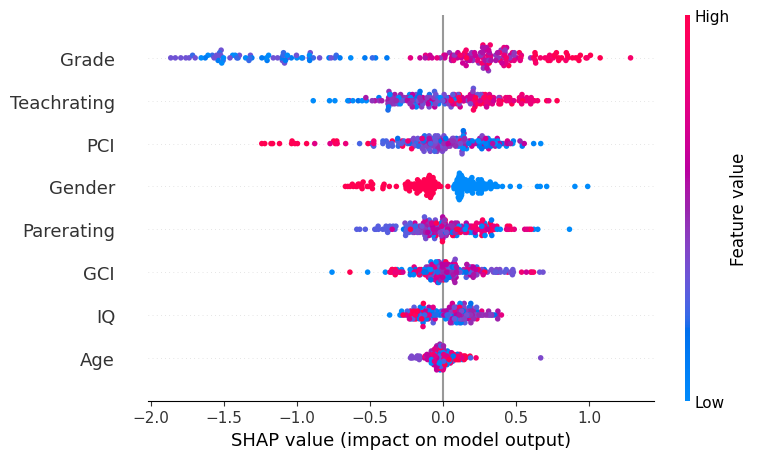

In [ ]:
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = extension_data[features]
y = extension_data['PCAdrawstn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

Saved: all_figures/figure_27.png


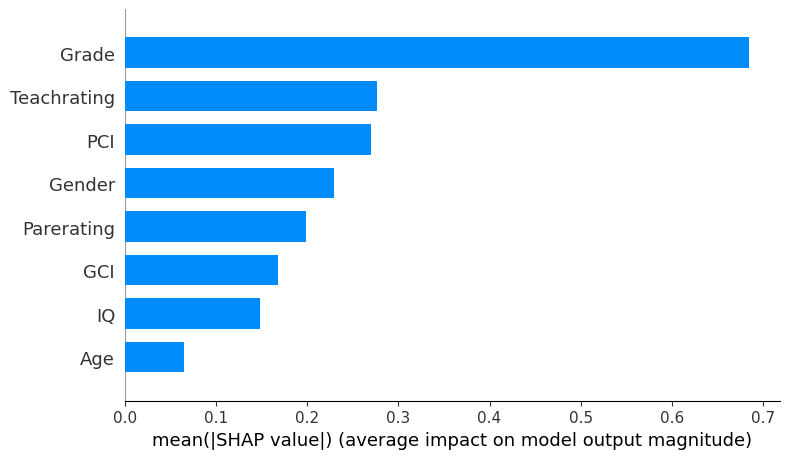

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_vars = extension_data[
    ['IQ','PCI','GCI',
     'PCAdrawstn','PCAcatestn']
].copy()

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_vars)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

sil_results = []

for k in range(2,7):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(cluster_scaled)

    sil = silhouette_score(
        cluster_scaled,
        labels
    )

    sil_results.append(
        [k,sil]
    )

pd.DataFrame(
    sil_results,
    columns=['Clusters','Silhouette']
)

,Clusters,Silhouette
0,2,0.317191
1,3,0.277160
2,4,0.246335
3,5,0.244779
4,6,0.241183


In [ ]:
k=3


MODEL FIT INDICES
   Profiles      AIC      BIC
0         1 -3455.12 -3333.95
1         2 -3581.01 -3334.19
2         3 -3593.05 -3220.57
3         4 -3591.40 -3093.26
4         5 -3565.39 -2941.60
5         6 -3530.16 -2780.72

Best solution based on BIC = 2

PROFILE COUNTS
           N      %
Profile            
1        358  54.49
2        299  45.51

PROFILE MEANS
             IQ     PCI     GCI  PCAdrawstn  PCAcatestn  PCASumStn
Profile                                                           
1        100.19   99.75  100.63        8.96        9.17      18.13
2        115.16  114.85  114.30       11.13       10.98      22.12

ANOVA RESULTS
IQ              F=598.02 p=0.00000
PCI             F=501.50 p=0.00000
GCI             F=426.03 p=0.00000
PCAdrawstn      F=114.64 p=0.00000
PCAcatestn      F=66.41 p=0.00000
PCASumStn       F=152.83 p=0.00000
Saved: all_figures/figure_28.png


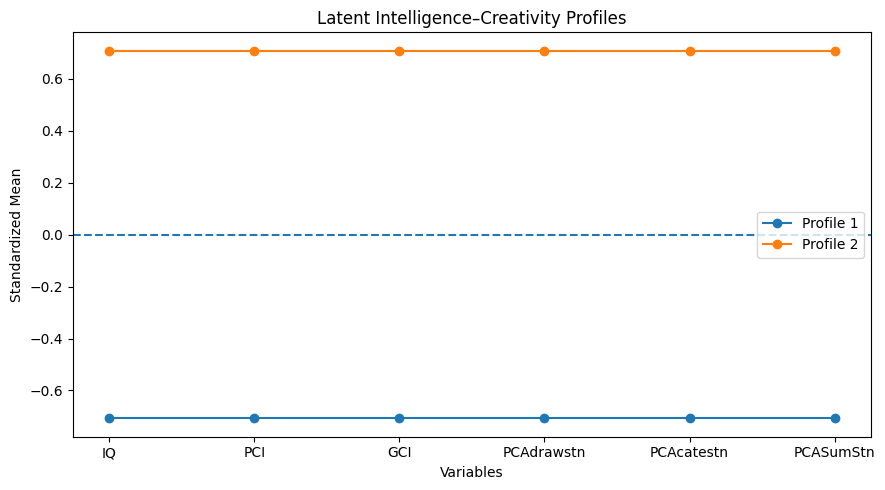


Saved: Figure4_Profiles.pdf


In [ ]:
import pandas as pd
import numpy as np

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from scipy.stats import f_oneway

import matplotlib.pyplot as plt

# ====================================================
# VARIABLES FOR LPA
# ====================================================

vars_lpa = [
    'IQ',
    'PCI',
    'GCI',
    'PCAdrawstn',
    'PCAcatestn',
    'PCASumStn'
]

lpa_data = data_clean[vars_lpa].dropna().copy()

# ====================================================
# STANDARDIZE VARIABLES
# ====================================================

scaler = StandardScaler()
X = scaler.fit_transform(lpa_data)

# ====================================================
# MODEL SELECTION
# ====================================================

print("\nMODEL FIT INDICES")
print("="*60)

fit_results = []

for k in range(1, 7):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X)

    fit_results.append([
        k,
        gmm.aic(X),
        gmm.bic(X)
    ])

fit_df = pd.DataFrame(
    fit_results,
    columns=['Profiles','AIC','BIC']
)

print(fit_df.round(2))

# ====================================================
# SELECT BEST MODEL
# ====================================================

best_k = fit_df.loc[
    fit_df['BIC'].idxmin(),
    'Profiles'
]

print("\nBest solution based on BIC =", best_k)

# ====================================================
# FINAL MODEL
# ====================================================

gmm_final = GaussianMixture(
    n_components=int(best_k),
    covariance_type='full',
    random_state=42
)

gmm_final.fit(X)

profiles = gmm_final.predict(X)

lpa_data['Profile'] = profiles + 1

# ====================================================
# PROFILE SIZES
# ====================================================

print("\nPROFILE COUNTS")
print("="*60)

counts = lpa_data['Profile'].value_counts().sort_index()

perc = (
    lpa_data['Profile']
    .value_counts(normalize=True)
    .sort_index()*100
)

profile_sizes = pd.DataFrame({
    'N': counts,
    '%': perc.round(2)
})

print(profile_sizes)

# ====================================================
# PROFILE MEANS
# ====================================================

print("\nPROFILE MEANS")
print("="*60)

profile_means = (
    lpa_data
    .groupby('Profile')[vars_lpa]
    .mean()
    .round(2)
)

print(profile_means)

# ====================================================
# ANOVA TESTS
# ====================================================

print("\nANOVA RESULTS")
print("="*60)

for v in vars_lpa:

    groups = [
        lpa_data.loc[
            lpa_data['Profile']==p,
            v
        ]
        for p in sorted(lpa_data['Profile'].unique())
    ]

    F,p = f_oneway(*groups)

    print(
        f"{v:15s} "
        f"F={F:.2f} "
        f"p={p:.5f}"
    )

# ====================================================
# FIGURE 4 PROFILE PLOT
# ====================================================

profile_z = (
    lpa_data
    .groupby('Profile')[vars_lpa]
    .mean()
)

profile_z = (
    profile_z
    - profile_z.mean()
) / profile_z.std()

plt.figure(figsize=(9,5))

for p in profile_z.index:

    plt.plot(
        vars_lpa,
        profile_z.loc[p],
        marker='o',
        label=f'Profile {p}'
    )

plt.axhline(
    y=0,
    linestyle='--'
)

plt.ylabel("Standardized Mean")
plt.xlabel("Variables")
plt.title("Latent Intelligence–Creativity Profiles")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure4_Profiles.pdf",
    bbox_inches='tight'
)

plt.show()

print("\nSaved: Figure4_Profiles.pdf")

In [ ]:
lpa_data.to_csv('lpa_data.csv', index=False)
print("Saved 'lpa_data.csv' to the current directory.")

Saved 'lpa_data.csv' to the current directory.


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import pandas as pd

vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating',
    'Parerating'
]

X = data_clean[vars_lpa].copy()

X_std = StandardScaler().fit_transform(X)

results = []

for k in range(2,7):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X_std)

    results.append([
        k,
        gmm.aic(X_std),
        gmm.bic(X_std)
    ])

fit_df = pd.DataFrame(
    results,
    columns=['Profiles','AIC','BIC']
)

print(fit_df)

   Profiles          AIC          BIC
0         2  9208.653274  9392.648318
1         3  9162.708216  9440.944625
2         4  9188.175048  9560.652822
3         5  9162.431443  9629.150581
4         6  8245.012841  8805.973344


In [ ]:
best_gmm = GaussianMixture(
    n_components=6,
    covariance_type='full',
    random_state=42
)

best_gmm.fit(X_std)

profiles = best_gmm.predict(X_std)

pd.Series(profiles+1).value_counts().sort_index()

,count
1,178
2,97
3,100
4,86
5,69
6,127


In [ ]:
best_k = 3

km = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

extension_data['Cluster'] = km.fit_predict(
    cluster_scaled
)

extension_data['Cluster'].value_counts()

,count
Cluster,
1,306
2,194
0,157


In [ ]:
for cov in ['full','diag','tied','spherical']:

    print("\n", cov)

    for k in range(2,7):

        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=42
        )

        gmm.fit(X_std)

        print(
            k,
            round(gmm.bic(X_std),2)
        )


 full
2 9392.65
3 9440.94
4 9560.65
5 9629.15
6 8805.97

 diag
2 9331.94
3 9315.9
4 9331.65
5 9362.68
6 8515.47

 tied
2 9350.9
3 9363.3
4 9335.95
5 9346.56
6 9373.75

 spherical
2 9357.48
3 9364.89
4 9323.54
5 9323.81
6 9320.93


In [ ]:
pd.Series(profiles+1).value_counts().sort_index()

,count
1,178
2,97
3,100
4,86
5,69
6,127


In [ ]:
profile_means

,IQ,PCI,GCI,PCAdrawstn,PCAcatestn,PCASumStn
Profile,,,,,,
1,100.19,99.75,100.63,8.96,9.17,18.13
2,115.16,114.85,114.30,11.13,10.98,22.12


In [ ]:
print(lpa_data.columns)

Index(['IQ', 'PCI', 'GCI', 'PCAdrawstn', 'PCAcatestn', 'PCASumStn', 'Profile'], dtype='object')


In [ ]:
print(data_clean.columns)

Index(['Grade', 'Age', 'Gender', 'PCI', 'GCI', 'IQ', 'PCAdrawstn',
       'PCAcatestn', 'PCASumStn', 'CIndex', 'Parerating', 'Teachrating',
       'seg1', 'seg2', 'pred', 'IQ2', 'IQ_Gender', 'IQ_Grade'],
      dtype='object')


In [ ]:
profile_means = (
    lpa_data
    .groupby('Profile')[
        ['IQ',
         'PCI',
         'GCI',
         'PCAdrawstn',
         'PCAcatestn',
         'PCASumStn']
    ]
    .mean()
    .round(2)
)

print(profile_means)
profile_sizes = (
    lpa_data['Profile']
    .value_counts()
    .sort_index()
)

print(profile_sizes)

             IQ     PCI     GCI  PCAdrawstn  PCAcatestn  PCASumStn
Profile                                                           
1        100.19   99.75  100.63        8.96        9.17      18.13
2        115.16  114.85  114.30       11.13       10.98      22.12
Profile
1    358
2    299
Name: count, dtype: int64


In [ ]:
vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating',
    'Parerating'
]

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import pandas as pd

vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating',
    'Parerating'
]

lpa_data = data_clean[vars_lpa].dropna()

X = StandardScaler().fit_transform(lpa_data)

for k in range(2,6):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='tied',
        random_state=42
    )

    gmm.fit(X)

    print(
        "Profiles =", k,
        "BIC =", round(gmm.bic(X),2)
    )

Profiles = 2 BIC = 9350.9
Profiles = 3 BIC = 9363.3
Profiles = 4 BIC = 9335.95
Profiles = 5 BIC = 9346.56


In [ ]:
vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn'
]

In [ ]:
vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn'
]

X = StandardScaler().fit_transform(
    data_clean[vars_lpa]
)

for k in range(2,6):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='tied',
        random_state=42
    )

    gmm.fit(X)

    print(
        k,
        round(gmm.bic(X),2)
    )

2 5587.56
3 5531.98
4 5540.63
5 5566.08


In [ ]:
vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating']


X = StandardScaler().fit_transform(
    data_clean[vars_lpa]
)

for k in range(2,6):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='tied',
        random_state=42
    )

    gmm.fit(X)

    print(
        k,
        round(gmm.bic(X),2)
    )

2 7518.06
3 7473.7
4 7439.63
5 7465.35


In [ ]:
cluster_summary = extension_data.groupby(
    'Cluster'
)[
    ['IQ','PCI','GCI',
     'PCAdrawstn',
     'PCAcatestn',
     'PCASumStn']
].mean()

cluster_summary

,IQ,PCI,GCI,PCAdrawstn,PCAcatestn,PCASumStn
Cluster,,,,,,
0,121.535032,121.294076,120.177898,8.803312,10.148662,18.951975
1,98.866013,98.769641,99.053431,8.844869,8.771634,17.616503
2,108.077320,107.129845,108.357371,12.626701,11.792680,24.419381


In [ ]:
vars_lpa = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating'
]

lpa_data = data_clean[vars_lpa].copy()

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

X = StandardScaler().fit_transform(lpa_data)

gmm = GaussianMixture(
    n_components=4,
    covariance_type='tied',
    random_state=42
)

gmm.fit(X)

lpa_data['Profile'] = gmm.predict(X) + 1

print(
    lpa_data['Profile']
    .value_counts()
    .sort_index()
)

print(
    lpa_data
    .groupby('Profile')
    .mean()
    .round(2)
)

Profile
1    235
2    152
3    170
4    100
Name: count, dtype: int64
             IQ  PCAdrawstn  PCAcatestn  Teachrating
Profile                                             
1        101.60        8.76        9.47       120.61
2        102.93        8.74        8.16        90.57
3        107.78       13.60       11.87       113.78
4        124.58        8.39       10.82       114.57


           IQ  PCAdrawstn  PCAcatestn  Teachrating
Profile                                           
1       -0.50       -0.42       -0.18         0.56
2       -0.38       -0.43       -0.62        -1.19
3        0.07        1.30        0.63         0.16
4        1.63       -0.56        0.28         0.21
Saved: all_figures/figure_29.png


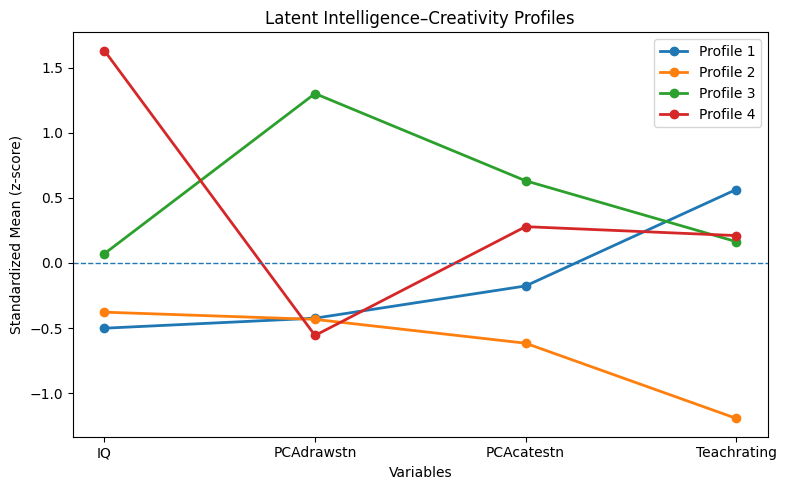

Saved: Figure4_Profiles.pdf
Saved: Figure4_Profiles.png


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =====================================================
# Variables used in the final LPA solution
# =====================================================

vars_plot = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating'
]

# =====================================================
# Standardize variables
# =====================================================

plot_data = data_clean[vars_plot].copy()

scaler = StandardScaler()
plot_z = pd.DataFrame(
    scaler.fit_transform(plot_data),
    columns=vars_plot
)

# Add profile membership
plot_z['Profile'] = lpa_data['Profile'].values

# =====================================================
# Profile means (standardized)
# =====================================================

profile_means = (
    plot_z
    .groupby('Profile')[vars_plot]
    .mean()
)

print(profile_means.round(2))

# =====================================================
# Create profile plot
# =====================================================

plt.figure(figsize=(8,5))

for profile in profile_means.index:

    plt.plot(
        vars_plot,
        profile_means.loc[profile],
        marker='o',
        linewidth=2,
        label=f'Profile {profile}'
    )

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.ylabel('Standardized Mean (z-score)')
plt.xlabel('Variables')
plt.title('Latent Intelligence–Creativity Profiles')
plt.legend()

plt.tight_layout()

plt.savefig(
    'Figure4_Profiles.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'Figure4_Profiles.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: Figure4_Profiles.pdf")
print("Saved: Figure4_Profiles.png")


In [ ]:
from scipy.stats import f_oneway

variables = [
    'IQ',
    'PCI',
    'GCI',
    'PCAdrawstn',
    'PCAcatestn',
    'PCASumStn'
]

for var in variables:

    groups = [
        extension_data[
            extension_data['Cluster']==c
        ][var]
        for c in sorted(
            extension_data['Cluster'].unique()
        )
    ]

    F,p = f_oneway(*groups)

    print(
        f"{var}: F={F:.2f}, p={p:.6f}"
    )

IQ: F=769.09, p=0.000000
PCI: F=522.64, p=0.000000
GCI: F=506.22, p=0.000000
PCAdrawstn: F=202.19, p=0.000000
PCAcatestn: F=74.97, p=0.000000
PCASumStn: F=233.08, p=0.000000


In [ ]:
!pip install pyclustering
!pip install pomegranate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 16.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=772edb8f360c307931d45181fd4b6c38acc5c0b73e8ef67566db7aa052c53c93
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.4/98.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.2 MB/s eta 0:00:00
  Created wheel for apricot-select: filename=apricot_select-0.6.1-py3-none-any.whl size=48767 sha256=e18021e6b0b4bfd51190b86001f8cdd3d08ebaf99cc9ff1da43c9c850b64f71b
  Stored in directory: /root/.cache/pip/wheels/19/ce/18/f10e7debb348bf14d4ab90c8b657a91a79f1106b699a1121c3
Successfully built apricot-select


In [ ]:
from sklearn.preprocessing import StandardScaler

lpa_vars = extension_data[
    ['IQ',
     'PCI',
     'GCI',
     'PCAdrawstn',
     'PCAcatestn']
].copy()

scaler = StandardScaler()

X_lpa = scaler.fit_transform(lpa_vars)

In [ ]:
from sklearn.mixture import GaussianMixture
import pandas as pd

fit_stats = []

for k in range(1, 7):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=20
    )

    gmm.fit(X_lpa)

    fit_stats.append({
        'Profiles': k,
        'AIC': gmm.aic(X_lpa),
        'BIC': gmm.bic(X_lpa)
    })

fit_df = pd.DataFrame(fit_stats)

fit_df

,Profiles,AIC,BIC
0,1,4012.945002,4102.698683
1,2,3871.276363,4055.271408
2,3,3844.661835,4122.898244
3,4,3848.574074,4221.051848
4,5,3846.292671,4313.011809
5,6,3797.833420,4358.793922


Saved: all_figures/figure_30.png


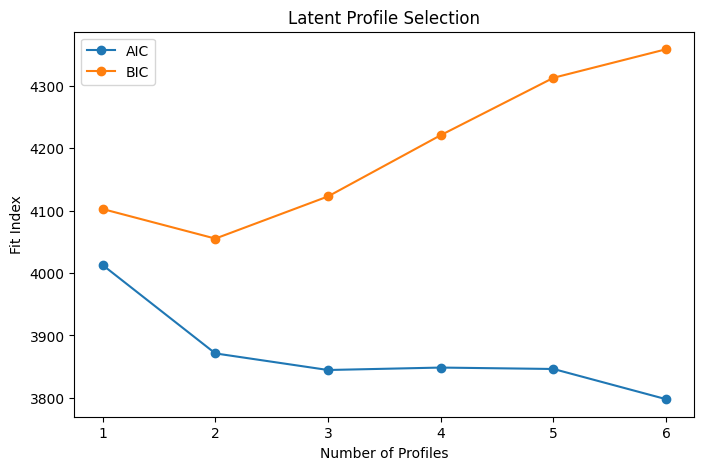

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    fit_df['Profiles'],
    fit_df['AIC'],
    marker='o',
    label='AIC'
)

plt.plot(
    fit_df['Profiles'],
    fit_df['BIC'],
    marker='o',
    label='BIC'
)

plt.xlabel('Number of Profiles')
plt.ylabel('Fit Index')
plt.title('Latent Profile Selection')
plt.legend()

plt.show()

In [ ]:
best_k = 3   # change if BIC suggests another value

gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=42,
    n_init=20
)

extension_data['LPA_Profile'] = gmm.fit_predict(X_lpa)

extension_data['LPA_Profile'].value_counts()

,count
LPA_Profile,
2,287
0,226
1,144


In [ ]:
profile_summary = extension_data.groupby(
    'LPA_Profile'
)[
    [
        'IQ',
        'PCI',
        'GCI',
        'PCAdrawstn',
        'PCAcatestn',
        'PCASumStn'
    ]
].mean()

profile_summary

,IQ,PCI,GCI,PCAdrawstn,PCAcatestn,PCASumStn
LPA_Profile,,,,,,
0,106.871681,105.396327,107.735133,12.468805,12.138407,24.607212
1,120.680556,121.339444,118.492431,8.860764,9.571736,18.432500
2,100.243902,100.200070,100.308571,8.516829,8.514390,17.031220


In [ ]:
import numpy as np

prob = gmm.predict_proba(X_lpa)

entropy = -np.sum(
    prob * np.log(prob + 1e-10)
) / len(prob)

max_entropy = np.log(prob.shape[1])

entropy_index = 1 - entropy/max_entropy

print("Entropy =", round(entropy_index,3))

Entropy = 0.601


Saved: all_figures/figure_31.png


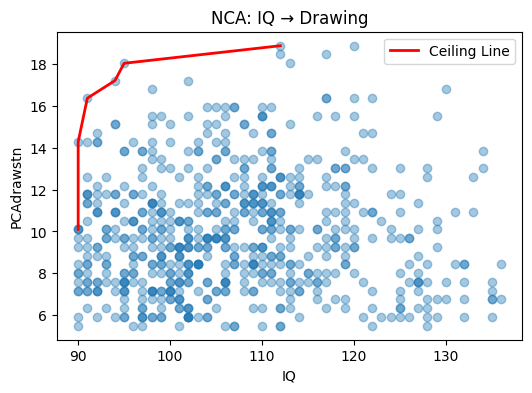

Saved: all_figures/figure_32.png


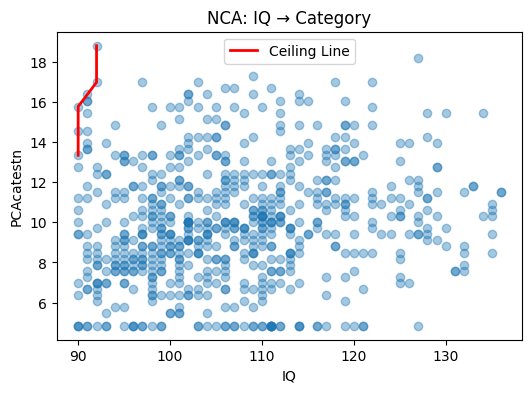

Saved: all_figures/figure_33.png


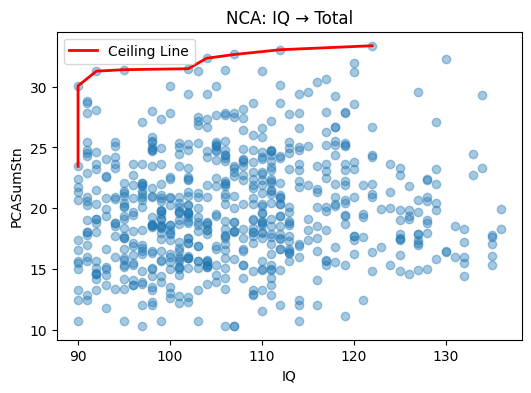

,Outcome,NCA_Effect_Size
0,Drawing,0.046
1,Category,0.009
2,Total,0.038


In [ ]:
# =====================================================
# NCA ANALYSIS
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

outcomes = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

nca_results = []

for name, target in outcomes.items():

    x = extension_data['IQ'].values
    y = extension_data[target].values

    # sort by IQ
    idx = np.argsort(x)
    x_sorted = x[idx]
    y_sorted = y[idx]

    # ceiling envelope
    ceiling_x = []
    ceiling_y = []

    current_max = -999999

    for xi, yi in zip(x_sorted, y_sorted):

        if yi > current_max:
            ceiling_x.append(xi)
            ceiling_y.append(yi)
            current_max = yi

    # Approximate ceiling area
    total_area = (
        (x.max()-x.min()) *
        (y.max()-y.min())
    )

    ceiling_area = 0

    for i in range(len(ceiling_x)-1):

        width = ceiling_x[i+1]-ceiling_x[i]

        height = (
            y.max()-ceiling_y[i]
        )

        ceiling_area += width*height

    effect_size = ceiling_area/total_area

    nca_results.append({
        "Outcome":name,
        "NCA_Effect_Size":round(effect_size,3)
    })

    # Plot
    plt.figure(figsize=(6,4))

    plt.scatter(x,y,alpha=.4)

    plt.plot(
        ceiling_x,
        ceiling_y,
        color='red',
        linewidth=2,
        label='Ceiling Line'
    )

    plt.xlabel("IQ")
    plt.ylabel(target)

    plt.title(f"NCA: IQ → {name}")

    plt.legend()

    plt.show()

nca_df = pd.DataFrame(nca_results)

nca_df

In [ ]:
# =====================================================
# FORMAL LATENT PROFILE ANALYSIS
# =====================================================

from sklearn.mixture import GaussianMixture
import pandas as pd
import numpy as np

lpa_vars = extension_data[
    [
        'IQ',
        'PCI',
        'GCI',
        'PCAdrawstn',
        'PCAcatestn'
    ]
]

fit_results = []

for k in range(1,7):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=20
    )

    gmm.fit(X_lpa)

    fit_results.append({

        'Profiles':k,

        'AIC':round(
            gmm.aic(X_lpa),2
        ),

        'BIC':round(
            gmm.bic(X_lpa),2
        ),

        'LogLik':round(
            gmm.score(X_lpa)*len(X_lpa),
            2
        )
    })

fit_df = pd.DataFrame(
    fit_results
)

fit_df

,Profiles,AIC,BIC,LogLik
0,1,4012.95,4102.70,-1986.47
1,2,3871.28,4055.27,-1894.64
2,3,3844.66,4122.90,-1860.33
3,4,3848.57,4221.05,-1841.29
4,5,3846.29,4313.01,-1819.15
5,6,3797.83,4358.79,-1773.92


In [ ]:
# =====================================================
# ENTROPY
# =====================================================

prob = gmm.predict_proba(X_lpa)

entropy = -np.sum(
    prob*np.log(prob+1e-10)
)/len(prob)

max_entropy = np.log(
    prob.shape[1]
)

entropy_index = (
    1 - entropy/max_entropy
)

print(
    "Entropy =",
    round(entropy_index,3)
)

Entropy = 0.743


In [ ]:
from scipy.stats import f_oneway

variables = [
    'IQ',
    'PCI',
    'GCI',
    'PCAdrawstn',
    'PCAcatestn',
    'PCASumStn'
]

anova_results = []

for var in variables:

    groups = [

        extension_data[
            extension_data[
                'LPA_Profile'
            ]==c
        ][var]

        for c in sorted(
            extension_data[
                'LPA_Profile'
            ].unique()
        )
    ]

    F,p = f_oneway(*groups)

    anova_results.append({

        'Variable':var,
        'F':round(F,2),
        'p':round(p,6)

    })

anova_df = pd.DataFrame(
    anova_results
)

anova_df

,Variable,F,p
0,IQ,359.91,0.0
1,PCI,335.00,0.0
2,GCI,230.99,0.0
3,PCAdrawstn,242.21,0.0
4,PCAcatestn,133.62,0.0
5,PCASumStn,417.56,0.0


Saved: all_figures/figure_34.png


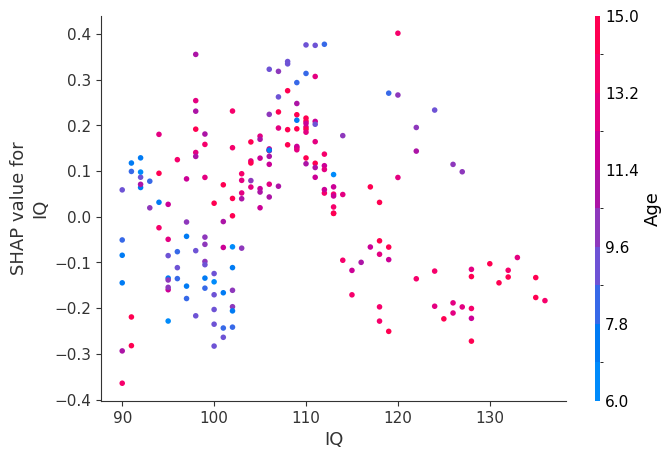

Saved: all_figures/figure_35.png


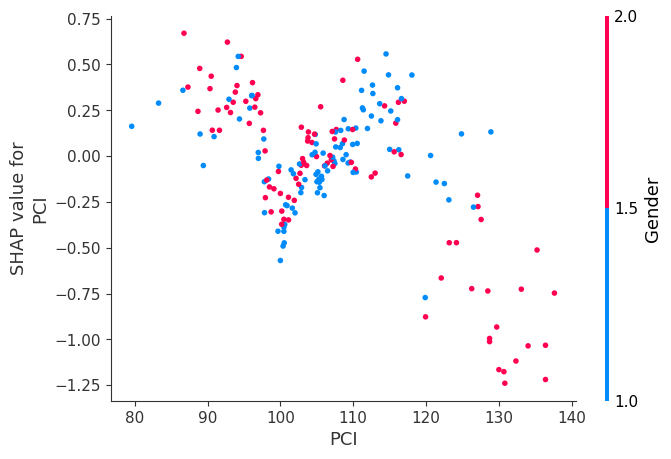

Saved: all_figures/figure_36.png


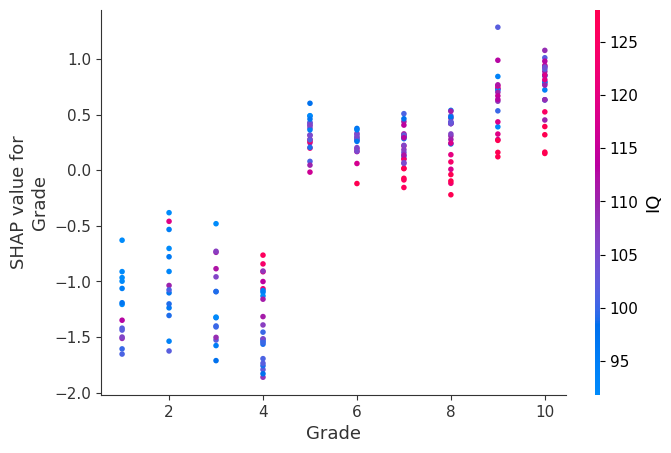

In [ ]:
shap.dependence_plot("IQ", shap_values, X_test)
shap.dependence_plot("PCI", shap_values, X_test)
shap.dependence_plot("Grade", shap_values, X_test)

In [ ]:
# =====================================================
# CROSS-VALIDATED BREAKPOINT ANALYSIS
# =====================================================

from sklearn.model_selection import train_test_split
import pwlf
import pandas as pd

targets = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

cv_results = []

train_df, test_df = train_test_split(
    extension_data,
    test_size=0.30,
    random_state=42
)

for name, target in targets.items():

    # TRAIN
    x_train = train_df['IQ'].values
    y_train = train_df[target].values

    pwlf_train = pwlf.PiecewiseLinFit(
        x_train,
        y_train
    )

    bp_train = pwlf_train.fit(2)[1]

    # TEST
    x_test = test_df['IQ'].values
    y_test = test_df[target].values

    pwlf_test = pwlf.PiecewiseLinFit(
        x_test,
        y_test
    )

    bp_test = pwlf_test.fit(2)[1]

    cv_results.append({
        "Outcome":name,
        "Train_BP":round(bp_train,2),
        "Test_BP":round(bp_test,2),
        "Difference":round(
            abs(bp_train-bp_test),2
        )
    })

cv_df = pd.DataFrame(cv_results)

cv_df

,Outcome,Train_BP,Test_BP,Difference
0,Drawing,110.0,120.0,10.0
1,Category,101.0,94.0,7.0
2,Total,106.0,122.0,16.0


In [ ]:
print(lpa_data.columns)

Index(['IQ', 'PCAdrawstn', 'PCAcatestn', 'Teachrating', 'Profile'], dtype='object')


In [ ]:
# =====================================================
# CROSS-VALIDATED BREAKPOINT ANALYSIS
# =====================================================

from sklearn.model_selection import train_test_split
import pwlf
import pandas as pd

targets = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

cv_results = []

train_df, test_df = train_test_split(
    extension_data,
    test_size=0.30,
    random_state=42
)

for name, target in targets.items():

    x_train = train_df['IQ'].values
    y_train = train_df[target].values

    train_pwlf = pwlf.PiecewiseLinFit(
        x_train,
        y_train
    )

    train_bp = train_pwlf.fit(2)[1]

    x_test = test_df['IQ'].values
    y_test = test_df[target].values

    test_pwlf = pwlf.PiecewiseLinFit(
        x_test,
        y_test
    )

    test_bp = test_pwlf.fit(2)[1]

    cv_results.append({
        'Outcome':name,
        'Train_BP':round(train_bp,2),
        'Test_BP':round(test_bp,2),
        'Difference':round(
            abs(train_bp-test_bp),2
        )
    })

cv_df = pd.DataFrame(
    cv_results
)

cv_df

,Outcome,Train_BP,Test_BP,Difference
0,Drawing,110.0,120.0,10.0
1,Category,101.0,94.0,7.0
2,Total,106.0,122.0,16.0


In [ ]:
# =====================================================
# CENTERED IQ
# =====================================================

extension_data['IQ_c'] = (
    extension_data['IQ']
    - extension_data['IQ'].mean()
)

extension_data['IQ_c2'] = (
    extension_data['IQ_c']**2
)

print(
    "Mean IQ_c:",
    extension_data['IQ_c'].mean()
)

Mean IQ_c: 1.7303932682133337e-15


In [ ]:
# =====================================================
# CENTERED QUADRATIC MODELS
# =====================================================

import statsmodels.api as sm
import pandas as pd

targets = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

centered_results = []

for name,target in targets.items():

    X = sm.add_constant(
        extension_data[
            ['IQ_c','IQ_c2']
        ]
    )

    y = extension_data[target]

    model = sm.OLS(
        y,
        X
    ).fit()

    centered_results.append({

        'Outcome':name,

        'R2':round(
            model.rsquared,
            3
        ),

        'IQ_c_p':round(
            model.pvalues['IQ_c'],
            4
        ),

        'IQ_c2_p':round(
            model.pvalues['IQ_c2'],
            4
        ),

        'Condition_Number':round(
            model.condition_number,
            2
        )
    })

centered_df = pd.DataFrame(
    centered_results
)

centered_df

,Outcome,R2,IQ_c_p,IQ_c2_p,Condition_Number
0,Drawing,0.026,0.0365,0.0000,250.06
1,Category,0.018,0.0020,0.9095,250.06
2,Total,0.019,0.0010,0.0137,250.06


In [ ]:
# =====================================================
# CENTER IQ
# =====================================================

extension_data['IQ_c'] = (
    extension_data['IQ']
    - extension_data['IQ'].mean()
)

extension_data['IQ_c2'] = (
    extension_data['IQ_c']**2
)

print(
    "Mean centered IQ:",
    extension_data['IQ_c'].mean()
)

Mean centered IQ: 1.7303932682133337e-15


In [ ]:
X_quad = sm.add_constant(
    extension_data[['IQ_c','IQ_c2']]
)

In [ ]:
data_full['IQ_c'] = (
    data_full['IQ']
    - data_full['IQ'].mean()
)

data_full['IQ_c2'] = (
    data_full['IQ_c']**2
)

X_clean = sm.add_constant(
    data_full[
        ['IQ_c',
         'IQ_c2',
         'Gender',
         'Grade']
    ]
)

In [ ]:
data_full['IQc_Gender'] = (
    data_full['IQ_c']
    * data_full['Gender']
)

data_full['IQc_Grade'] = (
    data_full['IQ_c']
    * data_full['Grade']
)

In [ ]:
X_int = sm.add_constant(
    data_full[
        [
            'IQ_c',
            'IQ_c2',
            'Gender',
            'Grade',
            'IQc_Gender',
            'IQc_Grade'
        ]
    ]
)

In [ ]:
print(X_int)

     const       IQ_c       IQ_c2  Gender  Grade  IQc_Gender   IQc_Grade
0      1.0  -8.926686   79.685727       1      1   -8.926686   -8.926686
1      1.0 -12.926686  167.099217       1      1  -12.926686  -12.926686
2      1.0 -13.926686  193.952589       1      1  -13.926686  -13.926686
3      1.0  -4.926686   24.272237       1      1   -4.926686   -4.926686
4      1.0 -12.926686  167.099217       1      1  -12.926686  -12.926686
..     ...        ...         ...     ...    ...         ...         ...
677    1.0  23.073314  532.377809       2     10   46.146628  230.733138
678    1.0  28.073314  788.110947       2     10   56.146628  280.733138
679    1.0  28.073314  788.110947       2     10   56.146628  280.733138
680    1.0  22.073314  487.231181       2     10   44.146628  220.733138
681    1.0  25.073314  628.671064       2     10   50.146628  250.733138

[682 rows x 7 columns]


In [ ]:
# =====================================================
# CENTERED QUADRATIC MODELS
# =====================================================

import statsmodels.api as sm
import pandas as pd

targets = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

centered_results = []

for name,target in targets.items():

    X = sm.add_constant(
        extension_data[
            ['IQ_c','IQ_c2']
        ]
    )

    y = extension_data[target]

    model = sm.OLS(
        y,
        X
    ).fit()

    centered_results.append({

        'Outcome':name,

        'R2':round(
            model.rsquared,
            3
        ),

        'IQ_c_p':round(
            model.pvalues['IQ_c'],
            4
        ),

        'IQ_c2_p':round(
            model.pvalues['IQ_c2'],
            4
        ),

        'Condition_Number':round(
            model.condition_number,
            2
        )
    })

centered_df = pd.DataFrame(
    centered_results
)

centered_df

,Outcome,R2,IQ_c_p,IQ_c2_p,Condition_Number
0,Drawing,0.026,0.0365,0.0000,250.06
1,Category,0.018,0.0020,0.9095,250.06
2,Total,0.019,0.0010,0.0137,250.06


In [ ]:
# =====================================================
# CROSS-VALIDATED BREAKPOINT ANALYSIS
# =====================================================

from sklearn.model_selection import train_test_split
import pwlf
import pandas as pd

targets = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

cv_results = []

train_df, test_df = train_test_split(
    extension_data,
    test_size=0.30,
    random_state=42
)

for name, target in targets.items():

    x_train = train_df['IQ'].values
    y_train = train_df[target].values

    train_pwlf = pwlf.PiecewiseLinFit(
        x_train,
        y_train
    )

    train_bp = train_pwlf.fit(2)[1]

    x_test = test_df['IQ'].values
    y_test = test_df[target].values

    test_pwlf = pwlf.PiecewiseLinFit(
        x_test,
        y_test
    )

    test_bp = test_pwlf.fit(2)[1]

    cv_results.append({
        'Outcome':name,
        'Train_BP':round(train_bp,2),
        'Test_BP':round(test_bp,2),
        'Difference':round(
            abs(train_bp-test_bp),2
        )
    })

cv_df = pd.DataFrame(
    cv_results
)

cv_df

,Outcome,Train_BP,Test_BP,Difference
0,Drawing,110.0,120.0,10.0
1,Category,101.0,94.0,7.0
2,Total,106.0,122.0,16.0


In [ ]:
# =====================================================
# CENTERED IQ
# =====================================================

extension_data['IQ_c'] = (
    extension_data['IQ']
    - extension_data['IQ'].mean()
)

extension_data['IQ_c2'] = (
    extension_data['IQ_c']**2
)

print(
    "Mean IQ_c:",
    extension_data['IQ_c'].mean()
)

Mean IQ_c: 1.7303932682133337e-15


In [ ]:
# =====================================================
# CENTERED QUADRATIC MODELS
# =====================================================

import statsmodels.api as sm
import pandas as pd

targets = {
    "Drawing":"PCAdrawstn",
    "Category":"PCAcatestn",
    "Total":"PCASumStn"
}

centered_results = []

for name,target in targets.items():

    X = sm.add_constant(
        extension_data[
            ['IQ_c','IQ_c2']
        ]
    )

    y = extension_data[target]

    model = sm.OLS(
        y,
        X
    ).fit()

    centered_results.append({

        'Outcome':name,

        'R2':round(
            model.rsquared,
            3
        ),

        'IQ_c_p':round(
            model.pvalues['IQ_c'],
            4
        ),

        'IQ_c2_p':round(
            model.pvalues['IQ_c2'],
            4
        ),

        'Condition_Number':round(
            model.condition_number,
            2
        )
    })

centered_df = pd.DataFrame(
    centered_results
)

centered_df

,Outcome,R2,IQ_c_p,IQ_c2_p,Condition_Number
0,Drawing,0.026,0.0365,0.0000,250.06
1,Category,0.018,0.0020,0.9095,250.06
2,Total,0.019,0.0010,0.0137,250.06


In [ ]:
print(lpa_data.head())
print(lpa_data.columns)
print(lpa_data.shape)

      IQ  PCAdrawstn  PCAcatestn  Teachrating  Profile
0   98.0        8.42        7.89        120.0        1
2   93.0        6.33        5.46         90.0        2
3  102.0        8.00        9.10        114.0        1
4   94.0        7.17        8.80         97.0        2
5   97.0        6.75       13.34         94.0        2
Index(['IQ', 'PCAdrawstn', 'PCAcatestn', 'Teachrating', 'Profile'], dtype='object')
(657, 5)


Saved: all_figures/figure_37.png


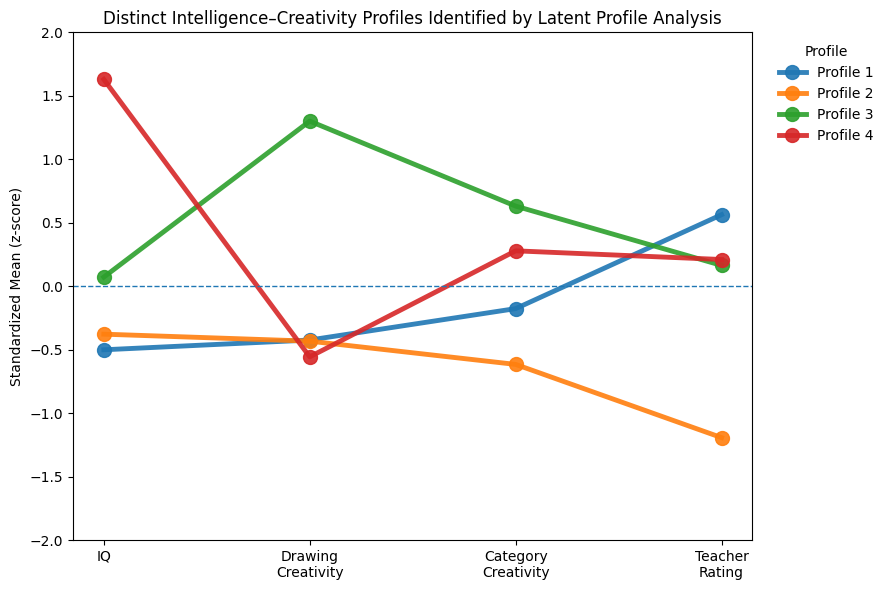


Profile Means (Standardized)
           IQ  PCAdrawstn  PCAcatestn  Teachrating
Profile                                           
1       -0.50       -0.42       -0.18         0.56
2       -0.38       -0.43       -0.62        -1.19
3        0.07        1.30        0.63         0.16
4        1.63       -0.56        0.28         0.21


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Variables used in the LPA
variables = [
    'IQ',
    'PCAdrawstn',
    'PCAcatestn',
    'Teachrating'
]

labels = [
    'IQ',
    'Drawing\nCreativity',
    'Category\nCreativity',
    'Teacher\nRating'
]

# --------------------------------------------------
# STANDARDIZE PARTICIPANT DATA FIRST
# --------------------------------------------------

lpa_std = lpa_data.copy()

for col in variables:
    lpa_std[col] = zscore(lpa_std[col])

# --------------------------------------------------
# COMPUTE PROFILE MEANS
# --------------------------------------------------

profile_means = (
    lpa_std
    .groupby('Profile')[variables]
    .mean()
)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

plt.figure(figsize=(9,6))

for profile in sorted(profile_means.index):

    plt.plot(
    labels,
    profile_means.loc[profile],
    marker='o',
    linewidth=3.5,
    markersize=10,
    alpha=0.9,
    label=f'Profile {profile}'
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.ylim(-2, 2)

plt.ylabel('Standardized Mean (z-score)')
plt.xlabel('')

plt.title(
    'Distinct Intelligence–Creativity Profiles Identified by Latent Profile Analysis'
)

plt.legend(
    title='Profile',
    bbox_to_anchor=(1.02,1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()

plt.savefig(
    'Latent_Profiles_Zscore.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# --------------------------------------------------
# OPTIONAL: PRINT PROFILE MEANS TABLE
# --------------------------------------------------

print("\nProfile Means (Standardized)")
print(profile_means.round(2))